# Linear Regression with Von Mises Loss for Cell Cycle Phase Prediction


**Key Features:**
- Von Mises negative log-likelihood loss with learnable κ (kappa) for uncertainty
- Geodesic loss
- Leave-one-experiment-out cross-validation with weighted averaging
- SHAP-based feature importance analysis


In [1]:
import sys
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
import pandas as pd

sys.path.insert(0, "/myhome/iris")

from src.data_pipeline.dataset import (
    ModularCellFeaturesDataset,
    create_transform_pipeline_from_config,
)
from src.data_pipeline.curve_projector import FucciCurveProjector
from src.evaluation.evaluator import Evaluator
from src.evaluation.metrics import MetricComputer

# Fix random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Imports loaded and random seeds fixed")

✓ Imports loaded and random seeds fixed


## 1. Setup and Configuration

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
h5_path = "/myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5"

# Hyperparameters
batch_size = 64
num_epochs = 100
learning_rate = 0.001
weight_decay = 1e-5


Using device: cuda


## 2. Load Dataset and Projector

In [3]:
from torch.utils.data import Dataset, DataLoader

# Dataset configuration
data_config = {
    "data_source": {"h5_path": h5_path, "quality_filters": {}},
    "image_transforms": [],
    "data_split": [0.7, 0.2, 0.1],
    "fucci_1D_projection": True,
    "projection_shape": "polygon",
    "fucci_transform": "log",
    "polynomial": 2,
    "feature_transforms": [{
        "class_path": "sklearn.preprocessing.StandardScaler",
        "init_args": {}
    }]
}

# Load dataset
print("Loading dataset...")
dataset = ModularCellFeaturesDataset(data_config=data_config, include_exp_id=True)

# Split into train/val/test
train_df, val_df, test_df = dataset.split_set()

all_feature_cols = [col for col in train_df.columns if col not in dataset.label_names and col != "exp_id"]
train_df_no_exp = train_df.drop(columns=["exp_id"])
val_df_no_exp = val_df.drop(columns=["exp_id"])
test_df_no_exp = test_df.drop(columns=["exp_id"])

# Create CV splits by exp_id
df = dataset.get_dataset_df()
exp_id_cv_splits = []
exp_ids = df["exp_id"].unique()

for exp_id in exp_ids:
    test_idx = df[df["exp_id"] == exp_id].index.to_numpy()
    hold_out_df = df[df["exp_id"] != exp_id]
    hold_out_idx = hold_out_df.index.to_numpy()
    np.random.shuffle(hold_out_idx)
    
    split_point = int(0.8 * len(hold_out_idx))
    train_idx = hold_out_idx[:split_point]
    val_idx = hold_out_idx[split_point:]
    
    exp_id_cv_splits.append({
        'exp_id': exp_id,
        'train_df': df.loc[train_idx].drop(columns=["exp_id"]),
        'val_df': df.loc[val_idx].drop(columns=["exp_id"]),
        'test_df': df.loc[test_idx].drop(columns=["exp_id"])
    })

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Number of experiments for CV: {len(exp_ids)}")

Loading dataset...

Creating feature transform pipeline
   - Using [{'class_path': 'sklearn.preprocessing.StandardScaler', 'init_args': {}}] transforms

Creating image transform pipeline
   - Using [] transforms

Creating data source from: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5
   ✓ Found 22,677 total cells

Applying quality filters:
   - Plane count: 3
   - Max objects: 1
   - Min segmentation pixels: 10
   - Max nuclei outside ratio: 0.2
   - Allowed exp_ids: None
   - Excluded exp_ids: ['NG012']
   - Filtering known duplicate cells: enabled
✓ Loaded filter results from cache: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_filtered_9167a645.json

FILTERING STATISTICS
Total cells:                22,677
Valid cells:                16,759
Invalid cells:              5,918

Rejection reasons:
  - nuclei_too_large              : 2,540
  - exp_id_excluded               : 1,223
  - multiple_cells                : 966
  - failed_

## 3. Define Linear Regression Model with Von Mises Output

In [4]:
class LinearRegressionVonMises(nn.Module):
    """
    Linear regression model with Von Mises output for circular prediction.
    
    Outputs:
        - mu: predicted phase (0-1, will be converted to angle)
        - log_kappa: log concentration parameter (learned, higher = more certain)
    """
    
    def __init__(self, input_dim, learn_kappa=True, init_kappa=1.0):
        super().__init__()
        self.linear_mu = nn.Linear(input_dim, 1)
        self.learn_kappa = learn_kappa
        
        if learn_kappa:
            # Learn kappa per-sample (heteroscedastic)
            self.linear_kappa = nn.Linear(input_dim, 1)
            # Initialize to reasonable values
            nn.init.zeros_(self.linear_kappa.weight)
            nn.init.ones_(self.linear_kappa.bias)   
        else:
            # Single global kappa
            self.kappa = nn.Parameter(torch.tensor(init_kappa))
    
    def forward(self, x):
        mu = self.linear_mu(x)
        
        if self.learn_kappa:
            kappa = self.linear_kappa(x)
            kappa = torch.clamp(kappa, min=0.001, max=10.0)
        else:
            kappa = self.kappa.expand(x.shape[0], 1)
        
        return mu, kappa
    
    def predict(self, x):
        """Return just the mean prediction (for evaluation)."""
        mu, _ = self.forward(x)
        return mu % 1.0


class LinearRegressionGeodesic(nn.Module):
    """Simple linear regression model for geodesic loss."""
    
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return self.linear(x)


# Get input dimension
input_dim = len(all_feature_cols)
print(f"Feature dimension: {input_dim}")

# Create model based on loss type

model_von_mises = LinearRegressionVonMises(input_dim=input_dim, learn_kappa=True).to(device)
model = LinearRegressionGeodesic(input_dim=input_dim).to(device)


Feature dimension: 54


## 4. Define Loss Functions (Geodesic and Von Mises)

In [5]:
class GeodesicLoss(nn.Module):
    """Geodesic distance loss for circular predictions."""
    
    def forward(self, predictions, targets):
        """
        Compute mean squared geodesic distance.
        
        Args:
            predictions: [B, 1] predicted phases
            targets: [B, 1] true phases
        """
        # circ_pred = predictions % 1.0
        circ_pred = predictions
        abs_residuals = torch.abs(targets - circ_pred)
        geodesic_distance = torch.min(abs_residuals, 1.0 - abs_residuals)
        return torch.mean(geodesic_distance ** 2)


class VonMisesNLLLoss(nn.Module):
    """
    Von Mises Negative Log-Likelihood Loss for circular data.
    
    The Von Mises distribution is the circular analogue of the Normal distribution.
    - mu: mean direction (angle)
    - kappa: concentration parameter (analogous to 1/variance)
    
    NLL = -log p(theta | mu, kappa) = -kappa * cos(theta - mu) + log(I_0(kappa)) + const
    
    Higher kappa = more concentrated = lower uncertainty (aleatoric)
    """

    def forward(self, predictions, von_mises_kappa, targets):
        """
        Compute mean squared geodesic distance.

        Args:
            predictions: Tensor [B, 1] with predicted phases
            targets: Tensor [B, 1] with true phases

        Returns:
            Mean squared geodesic distance
        """

        if von_mises_kappa is None:
            von_mises_kappa = torch.tensor(1.0, device=predictions.device)

        von_mises_kappa = von_mises_kappa.view(-1, 1)
        # If using von Mises distribution, apply circular transformation
        predictions_angle = (predictions - 0.5) * 2 * torch.pi
        targets_angle = (targets - 0.5) * 2 * torch.pi
        # Stability Trick: log(I0(k)) = k + log(i0e(k))
        log_bessel = von_mises_kappa + torch.log(torch.special.i0e(von_mises_kappa))

        # Loss = - (kappa * cos(diff) - log_bessel)
        #      = log_bessel - kappa * cos(diff)
        loss = torch.mean(
            log_bessel - von_mises_kappa * torch.cos(predictions_angle - targets_angle)
        )
        return loss
    

## 5. Define Optimizer and Training Loop

In [6]:
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

In [7]:
class DatasetWrapper(Dataset):
    def __init__(self, df, label_names, feature_cols):
        self.features = df[feature_cols].values.astype(np.float32)
        self.labels = df[label_names].values.astype(np.float32)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.labels[idx])


def train_epoch_vonmises(model, loader, optimizer, device):
    """Train for one epoch with Von Mises loss."""
    model.train()
    criterion = VonMisesNLLLoss()
    total_loss = 0.0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        mu, log_kappa = model(features)
        loss = criterion(mu, log_kappa, labels)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(loader)


def train_epoch_geodesic(model, loader, optimizer, device):
    """Train for one epoch with geodesic loss."""
    model.train()
    criterion = GeodesicLoss()
    total_loss = 0.0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate_model(model, loader, device, loss_type='vonmises'):
    """Evaluate model and return predictions with uncertainty."""
    model.eval()
    all_predictions = []
    all_labels = []
    all_kappas = []
    
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            
            if loss_type == 'vonmises':
                mu, log_kappa = model(features)
                predictions = mu % 1.0
                all_kappas.append(log_kappa.cpu().numpy())
            else:
                predictions = model(features) % 1.0
            
            all_predictions.append(predictions.cpu().numpy())
            all_labels.append(labels.numpy())
    
    predictions = np.concatenate(all_predictions, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    
    if loss_type == 'vonmises' and all_kappas:
        kappas = np.concatenate(all_kappas, axis=0)
    else:
        kappas = None
    
    return predictions, labels, kappas


## 6. Train Full Model

In [8]:
def train_model(model, epochs=num_epochs):
    # Create data loaders
    train_loader = DataLoader(
        DatasetWrapper(train_df_no_exp, dataset.label_names, all_feature_cols),
        shuffle=True, batch_size=batch_size
    )
    val_loader = DataLoader(
        DatasetWrapper(val_df_no_exp, dataset.label_names, all_feature_cols),
        shuffle=False, batch_size=batch_size
    )

    # Reset model
    if isinstance(model, LinearRegressionVonMises):
        model = LinearRegressionVonMises(input_dim=input_dim, learn_kappa=True).to(device)
        train_epoch = train_epoch_vonmises
        loss_type = 'vonmises'
    else:
        model = LinearRegressionGeodesic(input_dim=input_dim).to(device)
        train_epoch = train_epoch_geodesic
        loss_type = 'geodesic'

    criterion = GeodesicLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # Training loop
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in tqdm(range(epochs), desc="Training"):
        train_loss = train_epoch(model, train_loader, optimizer, device)
        
        # Validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                if loss_type == 'vonmises':
                    mu, log_kappa = model(features)
                    outputs = mu
                else:
                    outputs = model(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train: {train_loss:.4f}, Val: {val_loss:.4f}")

    print(f"\n✓ Training complete. Best validation loss: {best_val_loss:.4f}")

    # Load best model
    model.load_state_dict(best_model_state)
    return model, history

In [9]:
model_trained, history = train_model(model)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:  20%|██        | 20/100 [00:12<00:43,  1.83it/s]

Epoch [20/100] - Train: 0.0281, Val: 0.0286


Training:  40%|████      | 40/100 [00:23<00:35,  1.70it/s]

Epoch [40/100] - Train: 0.0278, Val: 0.0272


...

Epoch [60/100] - Train: 0.0271, Val: 0.0270


Training:  80%|████████  | 80/100 [00:46<00:11,  1.78it/s]

Epoch [80/100] - Train: 0.0269, Val: 0.0268


Training: 100%|██████████| 100/100 [00:57<00:00,  1.73it/s]

Epoch [100/100] - Train: 0.0268, Val: 0.0268

✓ Training complete. Best validation loss: 0.0267


In [14]:
model_von_mises, history_von_mises = train_model(model_von_mises)

Training:  20%|██        | 20/100 [00:13<00:55,  1.43it/s]

Epoch [20/100] - Train: -0.4298, Val: 0.0313


Training:  40%|████      | 40/100 [00:27<00:41,  1.44it/s]

Epoch [40/100] - Train: -0.4371, Val: 0.0308


Training:  60%|██████    | 60/100 [00:41<00:27,  1.44it/s]

Epoch [60/100] - Train: -0.4440, Val: 0.0306


Training:  80%|████████  | 80/100 [00:55<00:13,  1.45it/s]

Epoch [80/100] - Train: -0.4459, Val: 0.0306


Training: 100%|██████████| 100/100 [01:09<00:00,  1.45it/s]

Epoch [100/100] - Train: -0.4472, Val: 0.0309

✓ Training complete. Best validation loss: 0.0303


## 7. Evaluate Full Model

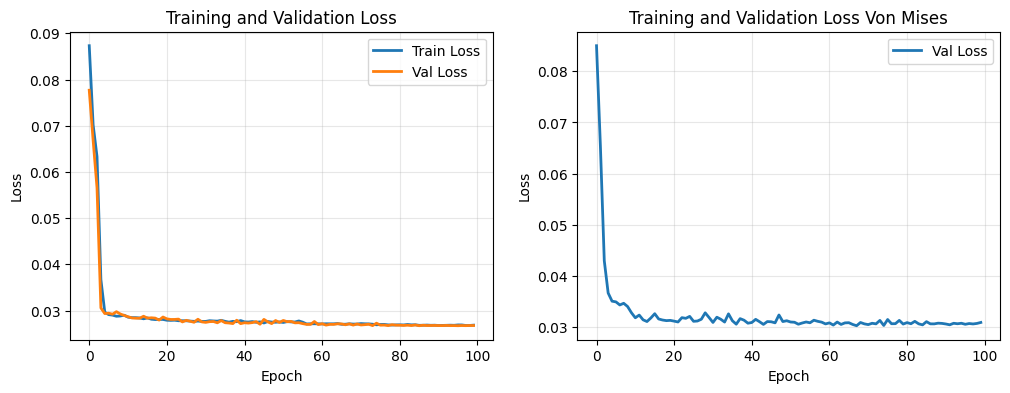

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history_von_mises['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Von Mises')
ax.legend()
ax.grid(True, alpha=0.3)

# Evaluate on test set
evaluator = Evaluator(projector=dataset.projector)
evaluator.config.plots_to_generate = ["scatter", "geodesic_residual"]

test_loader = DataLoader(
        DatasetWrapper(test_df_no_exp, dataset.label_names, all_feature_cols),
        shuffle=False, batch_size=batch_size
    )

/myhome/iris/src/evaluation/plots.py:284: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(fontsize=self.config.label_fontsize)



Test Set Results:
  Geodesic MAE:  0.1311
  Geodesic RMSE: 0.1658
  Geodesic R²:   0.4270


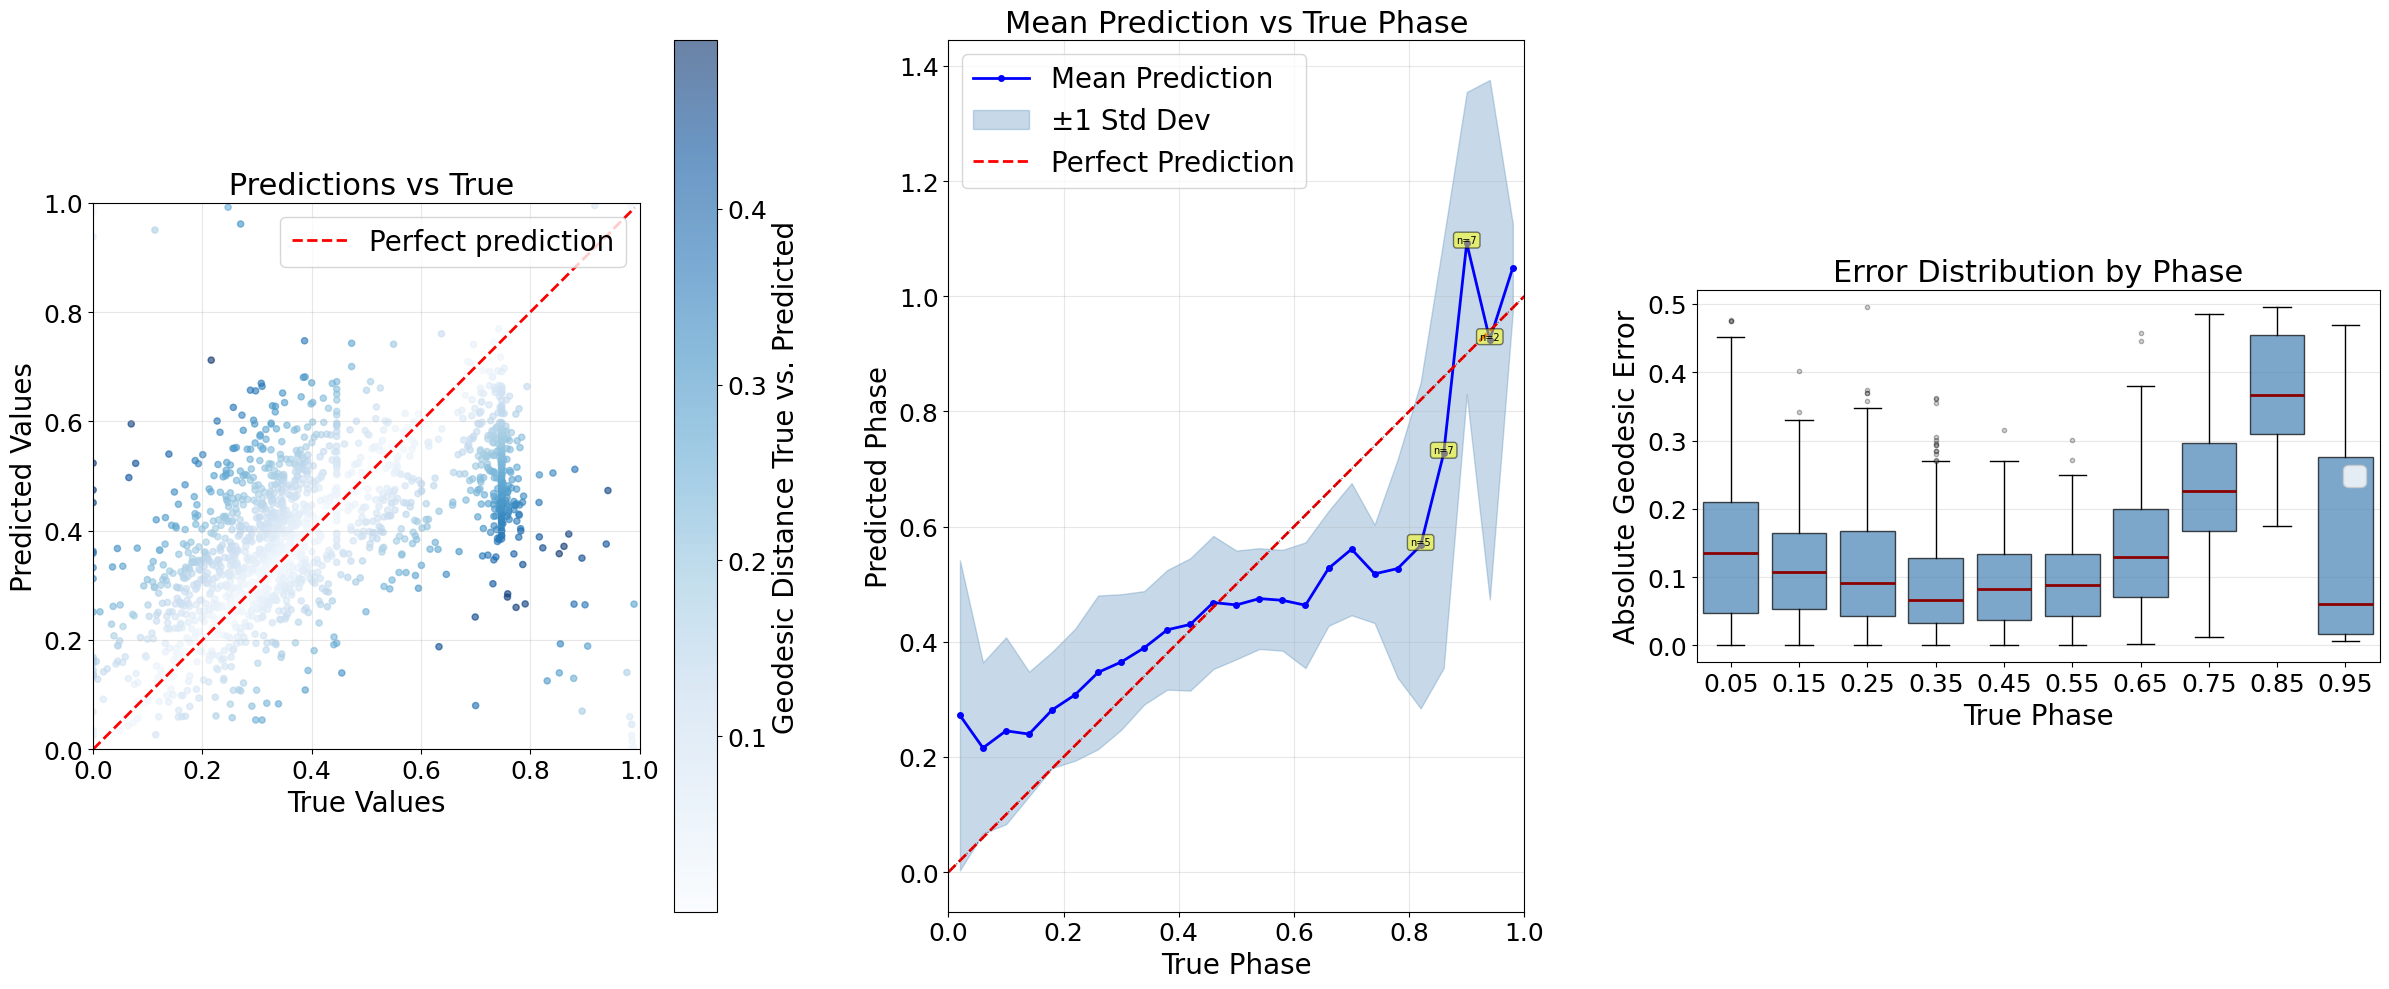

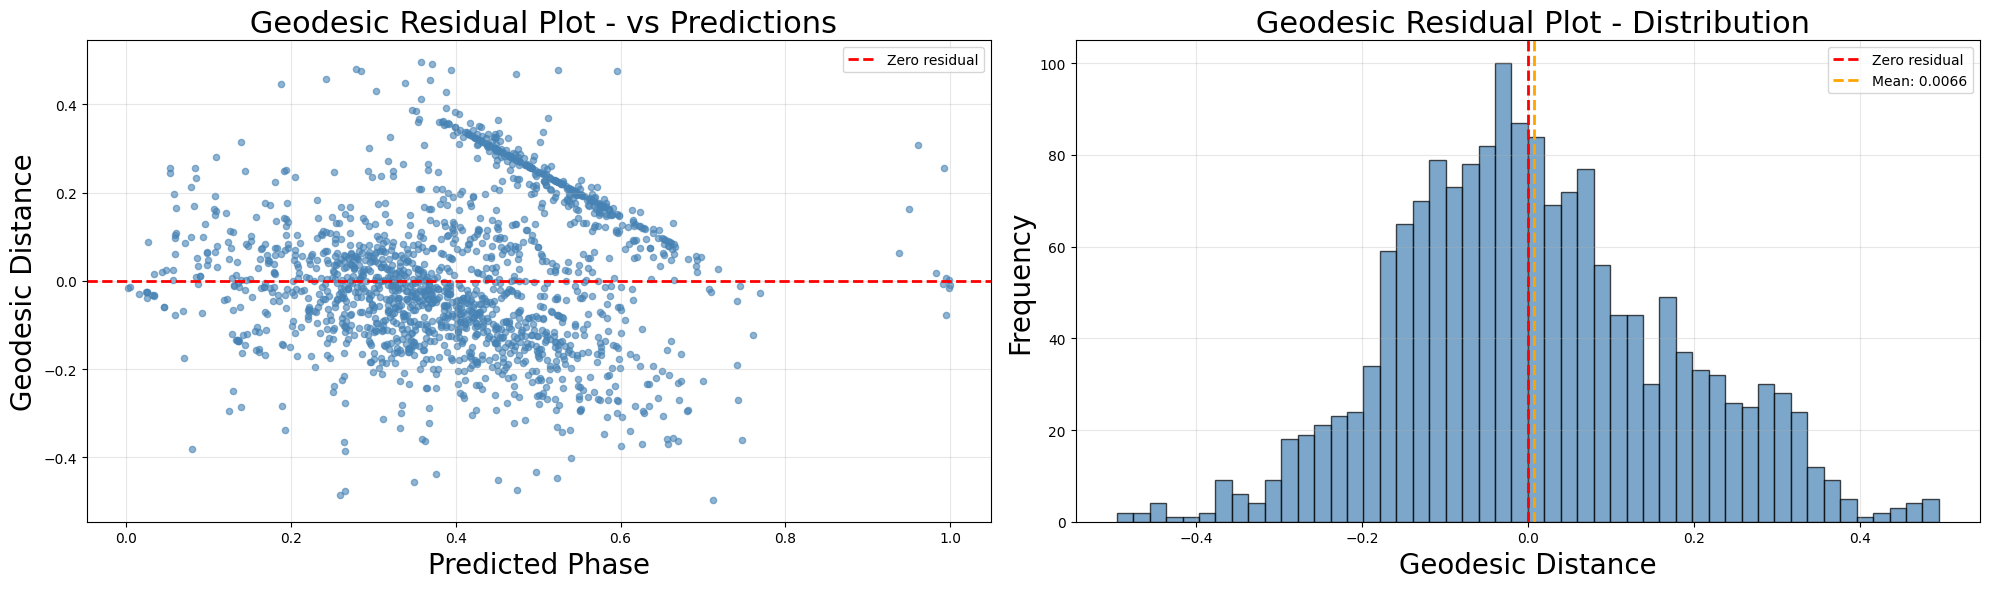

In [12]:
test_predictions, test_labels, test_kappas = evaluate_model(
    model_trained, test_loader, device, loss_type="geodesic"
)

results_test = evaluator.evaluate(test_labels, test_predictions)


print(f"\nTest Set Results:")
print(f"  Geodesic MAE:  {results_test.metrics.geodesic_mae:.4f}")
print(f"  Geodesic RMSE: {results_test.metrics.geodesic_rmse:.4f}")
print(f"  Geodesic R²:   {results_test.metrics.geodesic_r2:.4f}")

/myhome/iris/src/evaluation/plots.py:284: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(fontsize=self.config.label_fontsize)



Test Set Results:
  Geodesic MAE:  0.1348
  Geodesic RMSE: 0.1757
  Geodesic R²:   0.3565


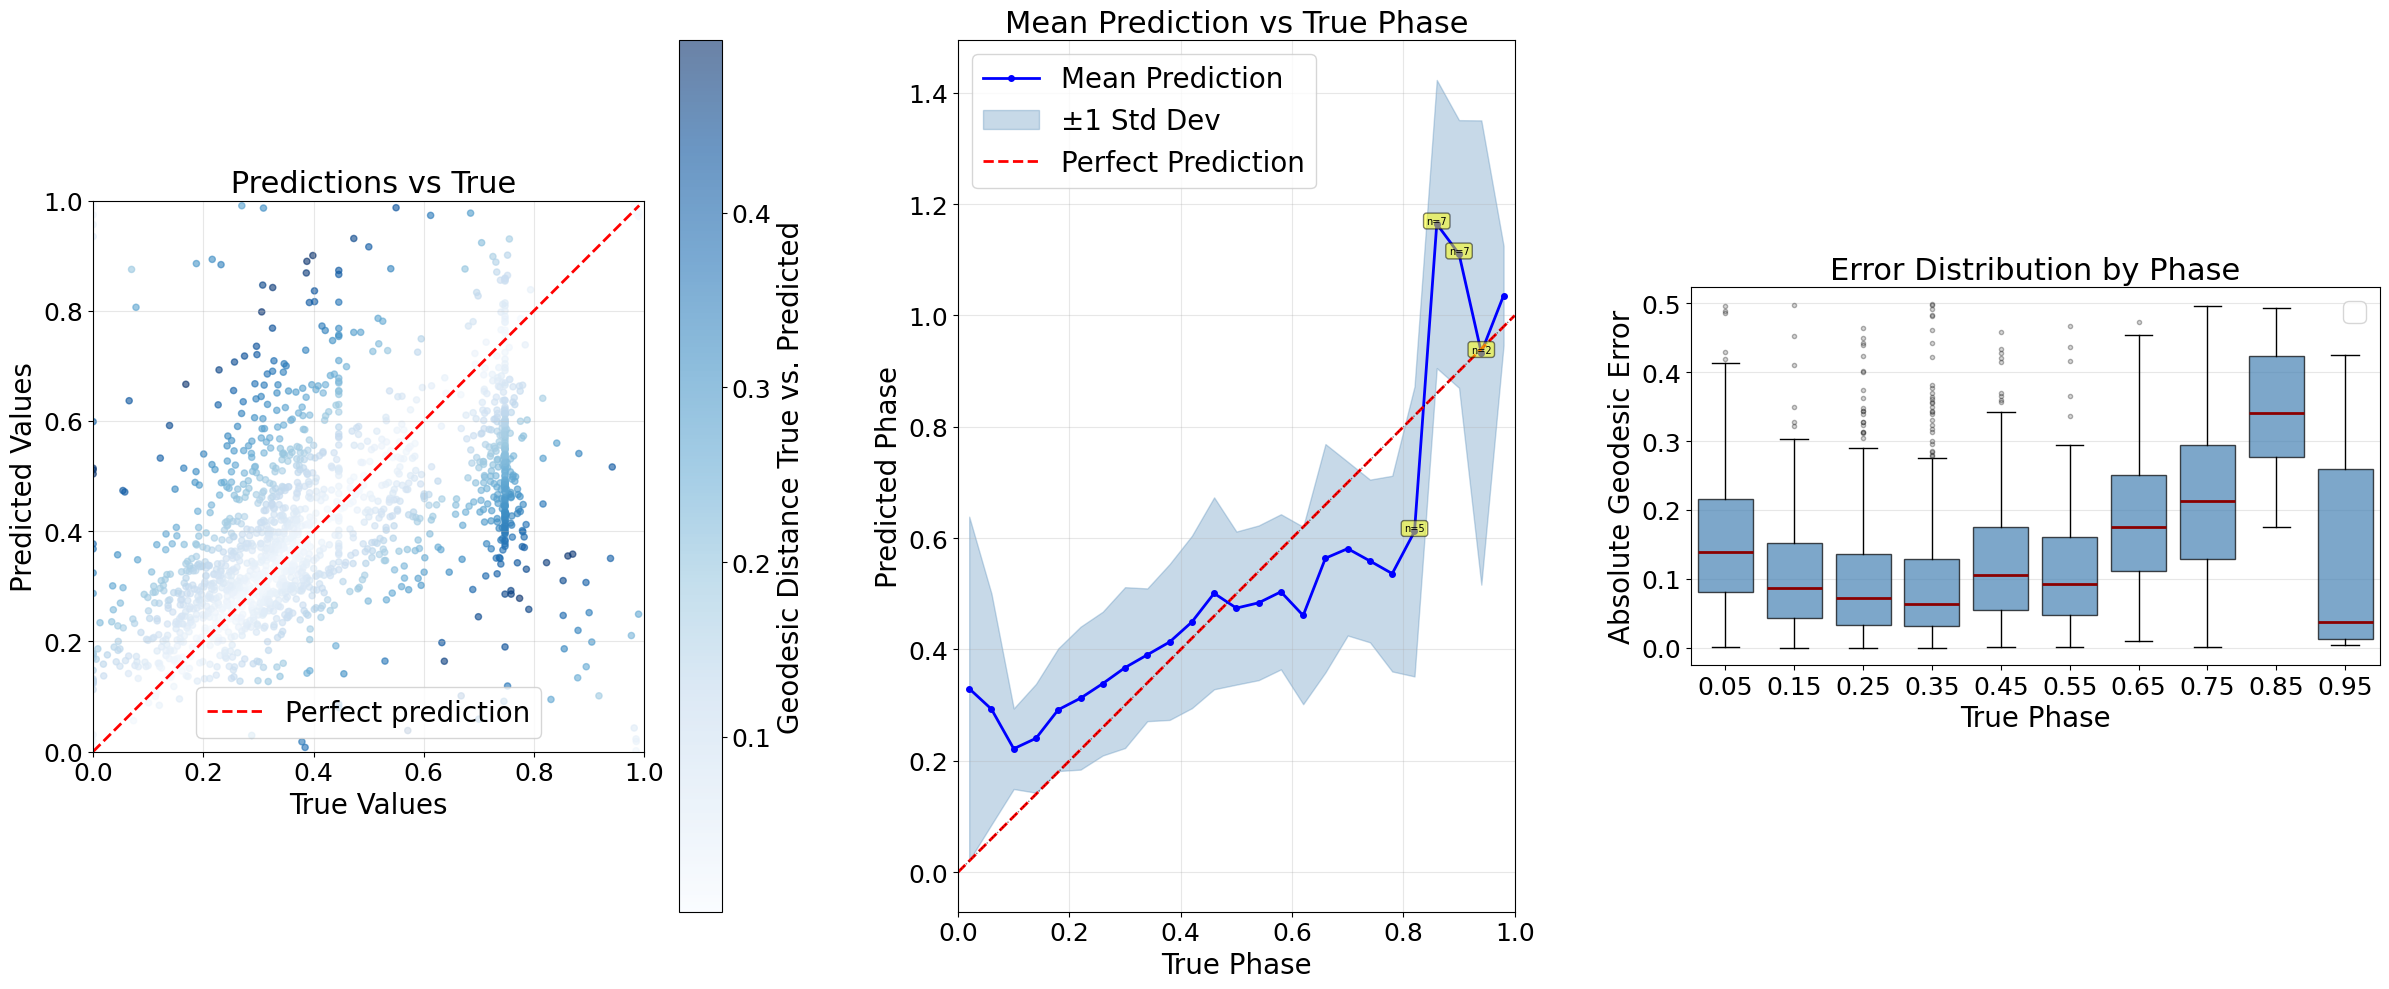

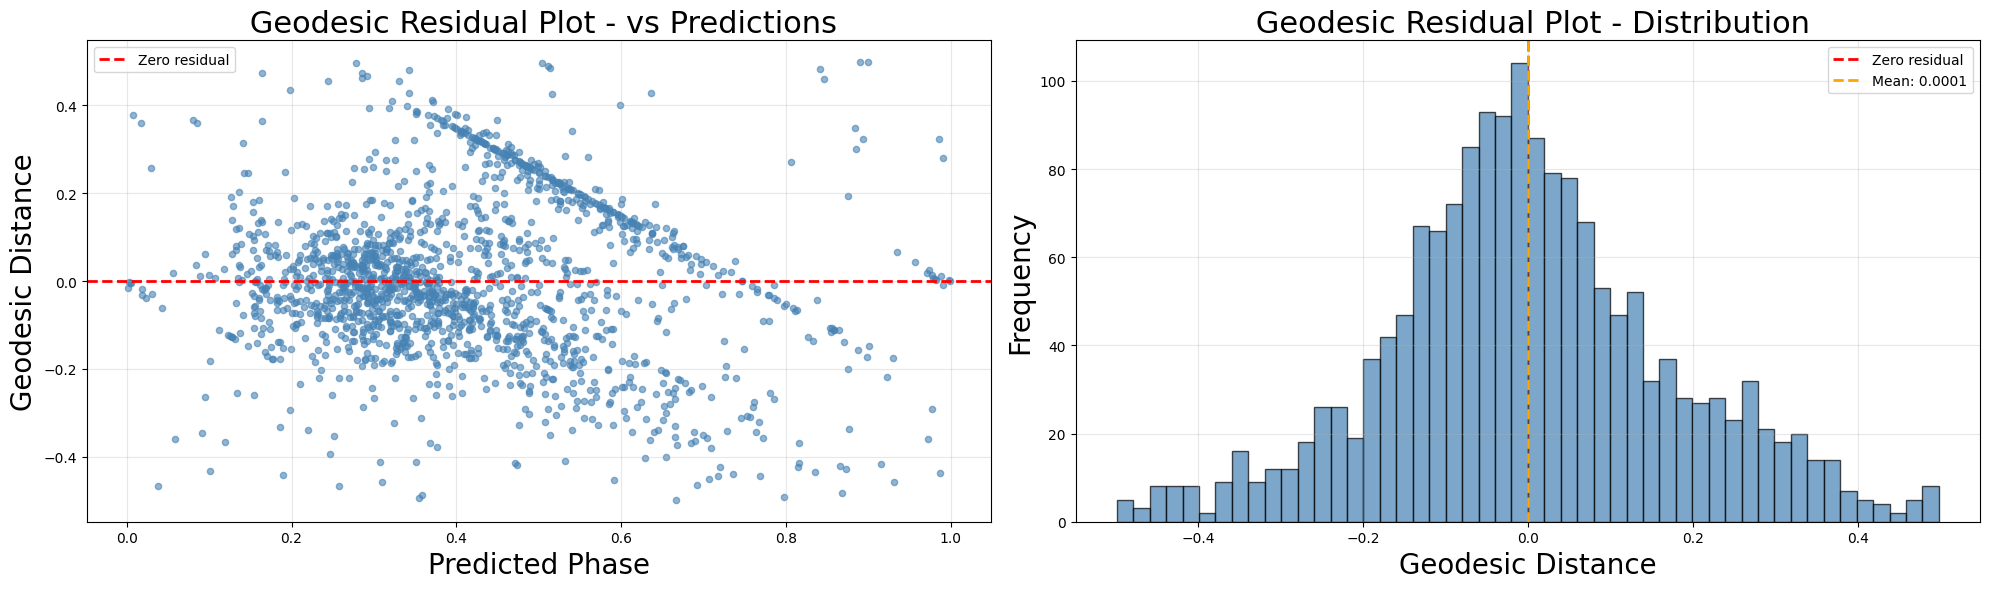

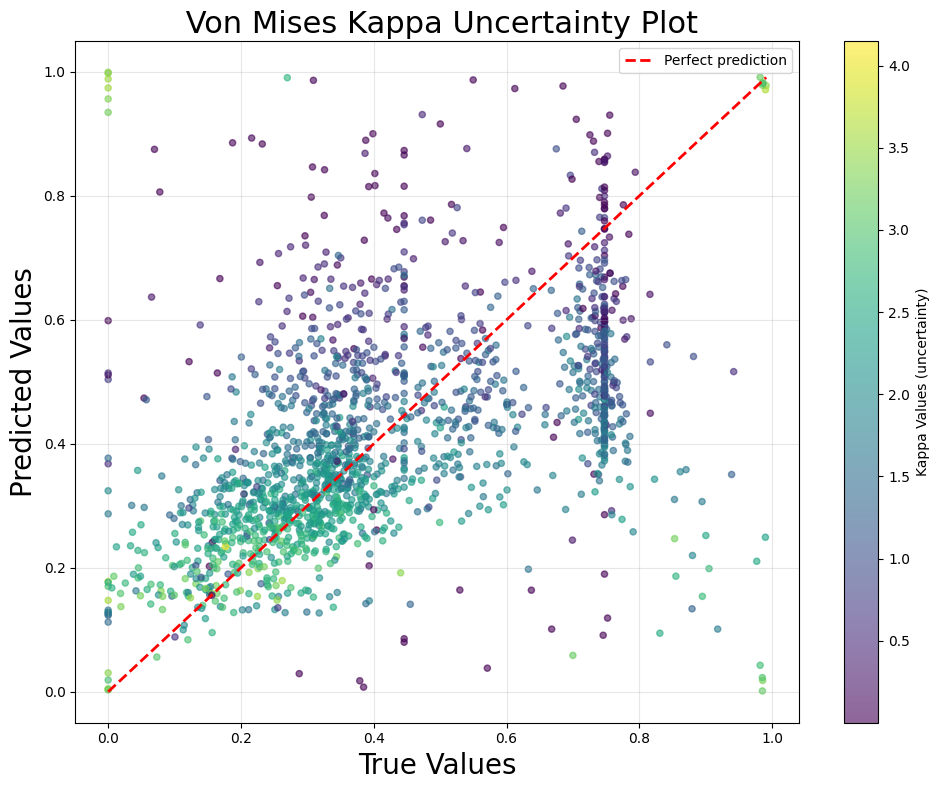

In [16]:
test_predictions, test_labels, test_kappas = evaluate_model(
    model_von_mises, test_loader, device, loss_type="vonmises"
)
evaluator.config.plots_to_generate.append("von_mises_kappa_uncertainty")
results_test = evaluator.evaluate(test_labels, test_predictions, test_kappas)


print(f"\nTest Set Results:")
print(f"  Geodesic MAE:  {results_test.metrics.geodesic_mae:.4f}")
print(f"  Geodesic RMSE: {results_test.metrics.geodesic_rmse:.4f}")
print(f"  Geodesic R²:   {results_test.metrics.geodesic_r2:.4f}")

## 8. Cross-Validation with Experiment Holdout

In [14]:
def train_linear_model(train_df, val_df, test_df, exp_id=None, verbose=True):
    """
    Train linear regression model with Von Mises or Geodesic loss.
    """
    # Create data loaders
    train_loader = DataLoader(
        DatasetWrapper(train_df, dataset.label_names, all_feature_cols),
        shuffle=True, batch_size=batch_size
    )
    val_loader = DataLoader(
        DatasetWrapper(val_df, dataset.label_names, all_feature_cols),
        shuffle=False, batch_size=batch_size
    )
    test_loader = DataLoader(
        DatasetWrapper(test_df, dataset.label_names, all_feature_cols),
        shuffle=False, batch_size=batch_size
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    criterion = GeodesicLoss()
    # Training
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    max_patience = 30
    
    for epoch in range(num_epochs):
        train_loss = train_epoch_geodesic(model, train_loader, optimizer, device)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                break
    
    # Load best model and evaluate
    model.load_state_dict(best_model_state)
    test_predictions, test_labels, test_kappas = evaluate_model(model, test_loader, device, loss_type='geodesic')
    
    evaluator = Evaluator(projector=dataset.projector)
    evaluator.config.plots_to_generate = ["scatter", "geodesic_residual"]
    results_test = evaluator.evaluate(test_labels, test_predictions, prefix=exp_id)
    
    if verbose:
        exp_str = f"holdout {exp_id}" if exp_id else "full dataset"
        print(f"Linear ({exp_str}): "
              f"Test MAE={results_test.metrics.geodesic_mae:.4f}, "
              f"R²={results_test.metrics.geodesic_r2:.4f}")
    
    return model, results_test, test_kappas

print("✓ CV training function defined")

✓ CV training function defined


CROSS-VALIDATION: LEAVE-ONE-EXPERIMENT-OUT


Cross-validation:  83%|████████▎ | 10/12 [06:26<01:12, 36.09s/it]/myhome/iris/src/evaluation/plots.py:117: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=self.config.dpi)
Cross-validation: 100%|██████████| 12/12 [07:32<00:00, 37.67s/it]



CROSS-VALIDATION RESULTS BY EXPERIMENT
exp_id  n_train  n_val  n_test  geodesic_mae  geodesic_rmse  geodesic_r2  geodesic_mse
 CL023    11940   2986    1833      0.136672       0.166437     0.370088      0.027701
 JP242    10144   2537    4078      0.124379       0.161875     0.544212      0.026203
 JP277    11945   2987    1827      0.131300       0.166266     0.319464      0.027644
 NG015    12580   3146    1033      0.124464       0.155669     0.353830      0.024233
 NG016    12529   3133    1097      0.120058       0.151614     0.389916      0.022987
 NG018    13106   3277     376      0.117993       0.149680     0.314110      0.022404
 NG019    12547   3137    1075      0.136027       0.171140     0.204400      0.029289
 NG026    12662   3166     931      0.157459       0.193591     0.334407      0.037477
 NG028    12560   3141    1058      0.150491       0.190515     0.386057      0.036296
 NG029    12833   3209     717      0.138242       0.164296     0.046019      0.026993
 NG

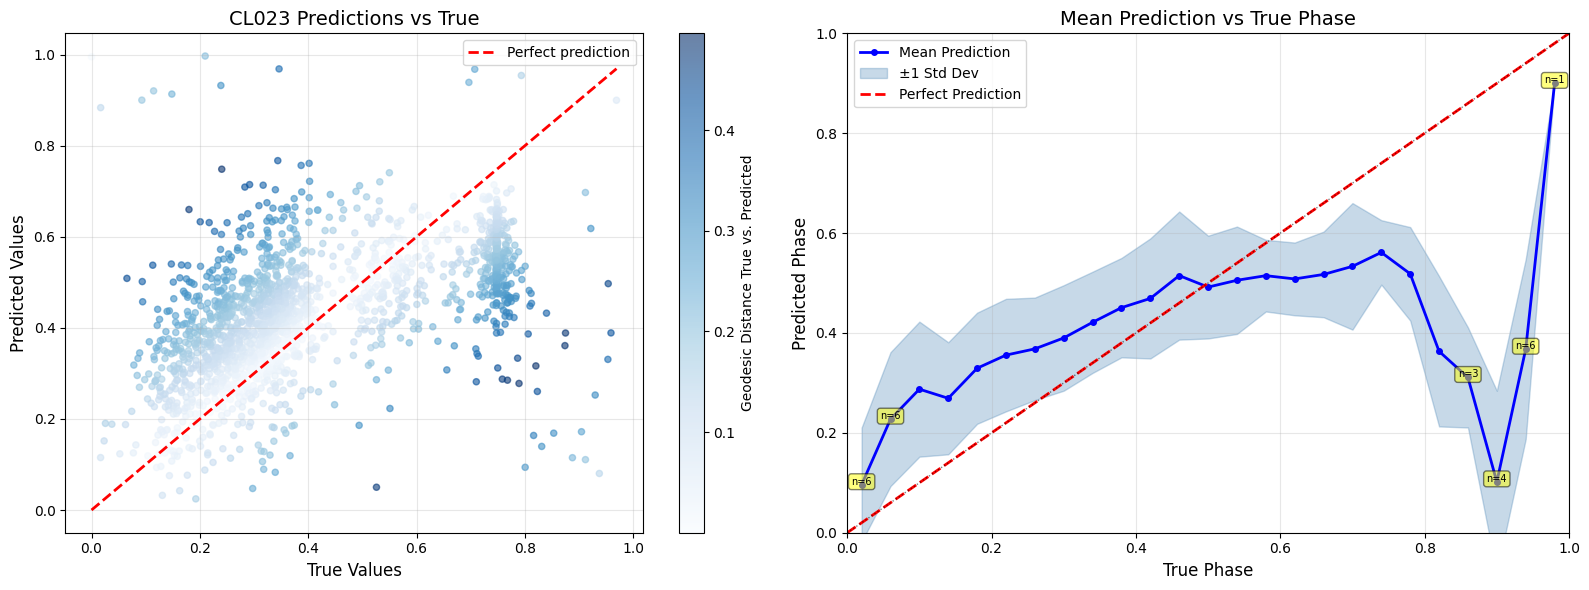

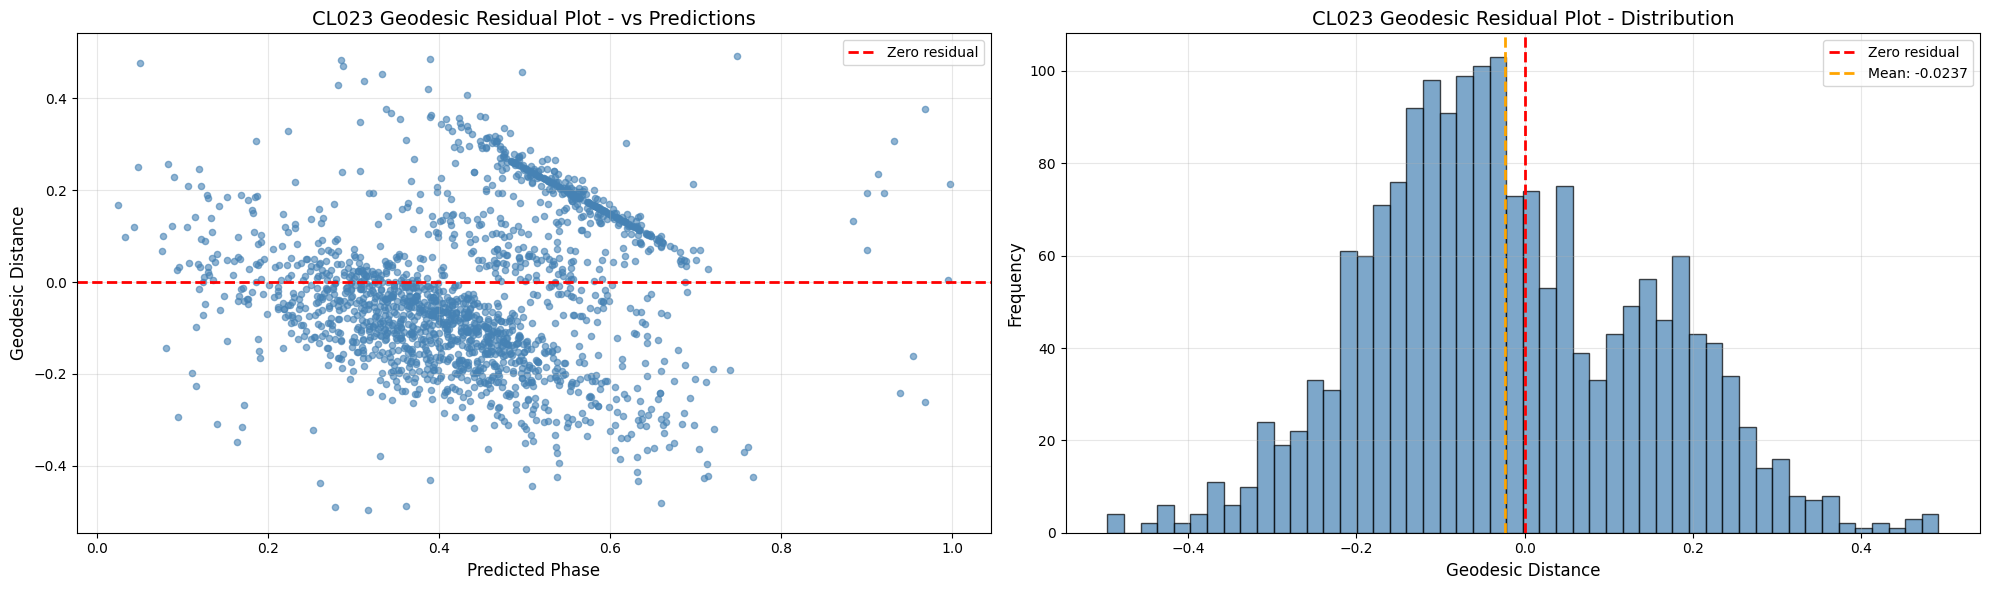

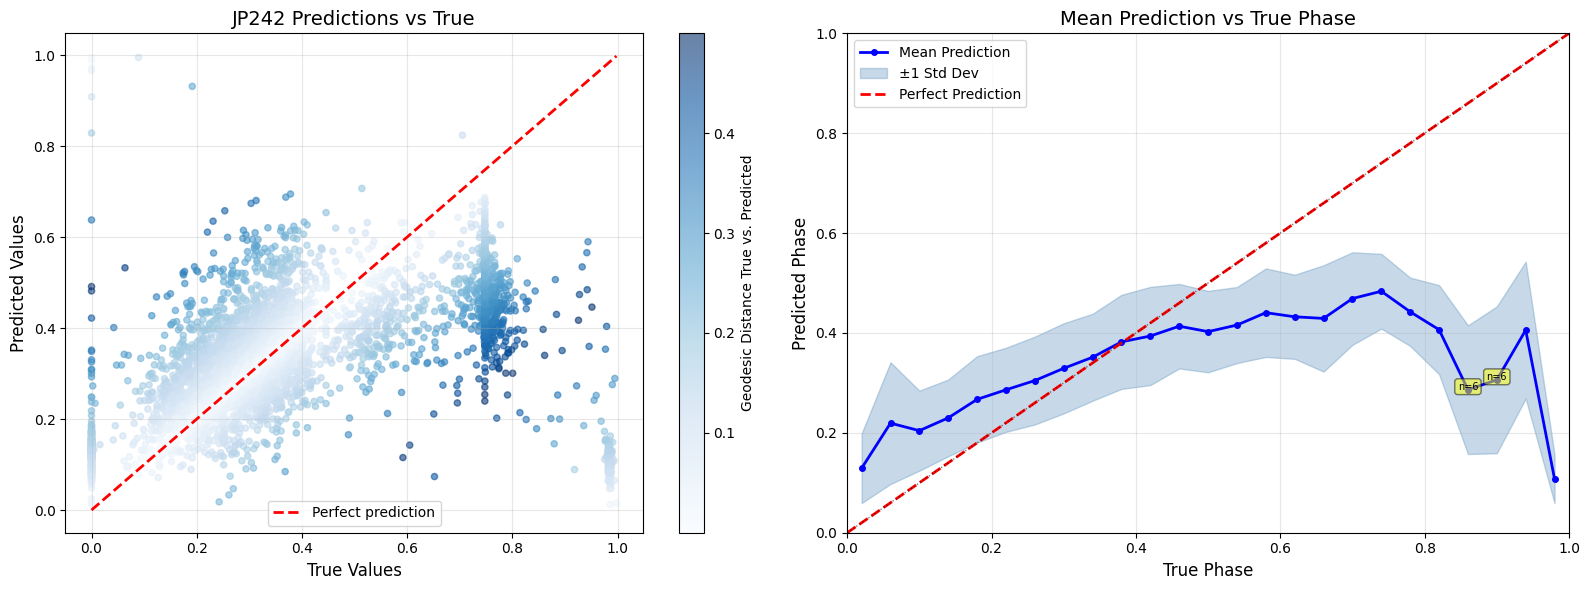

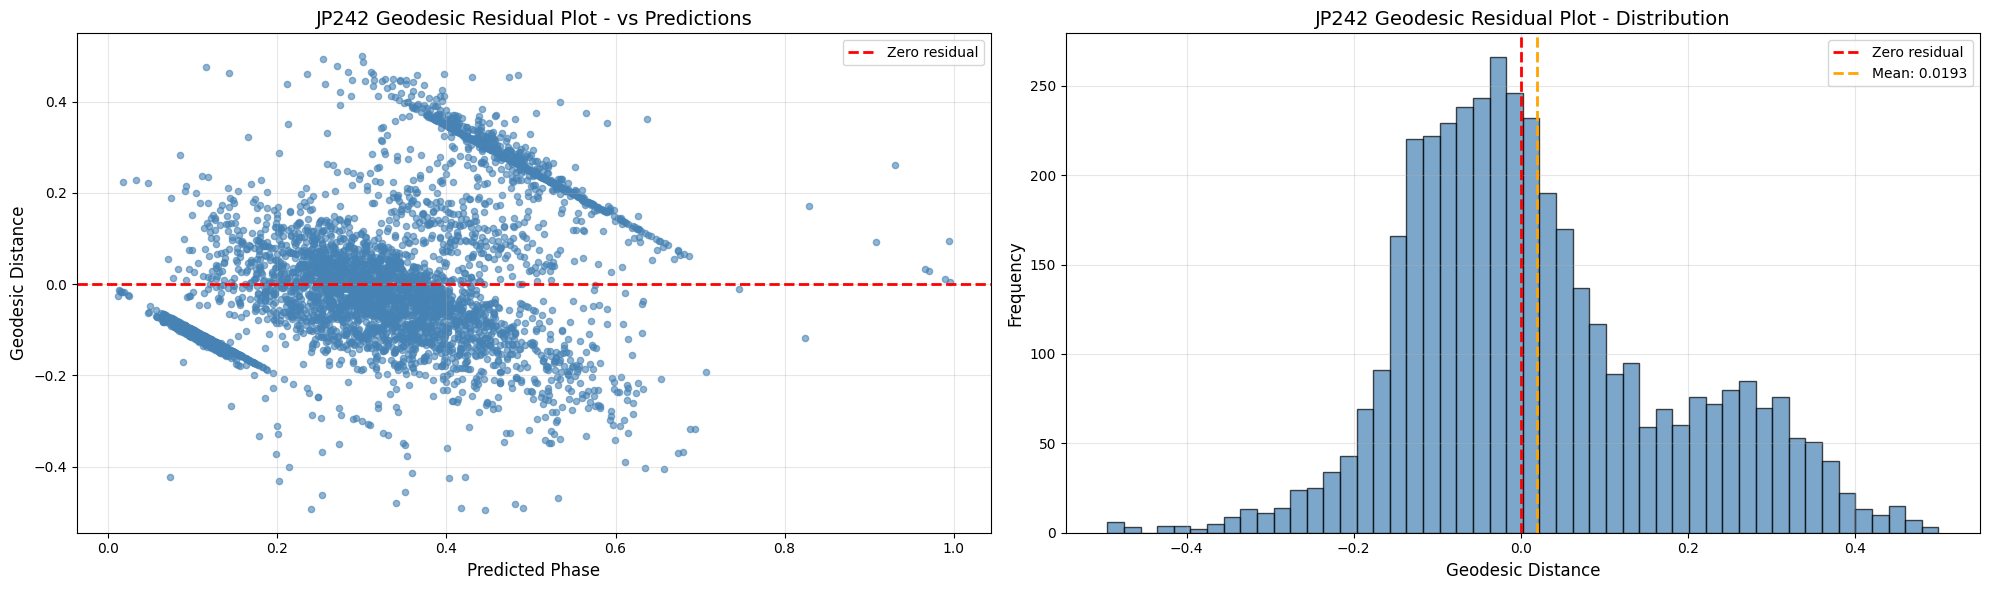

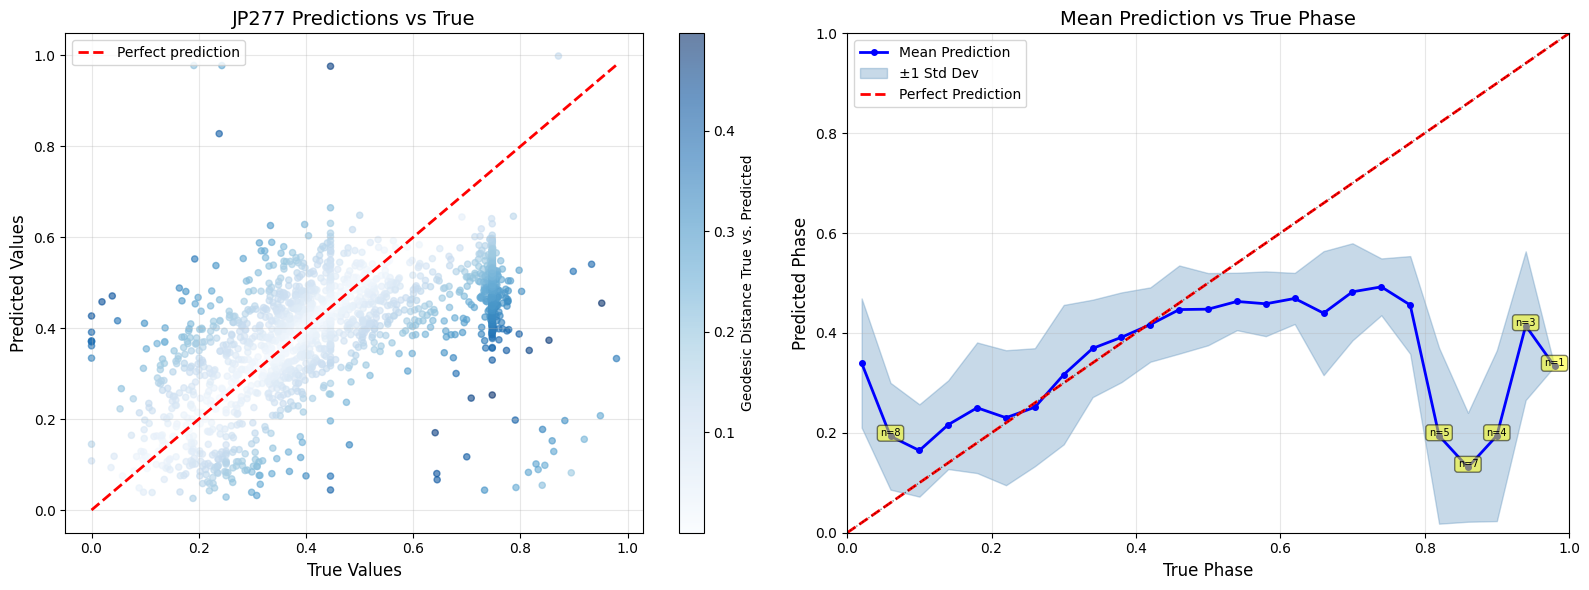

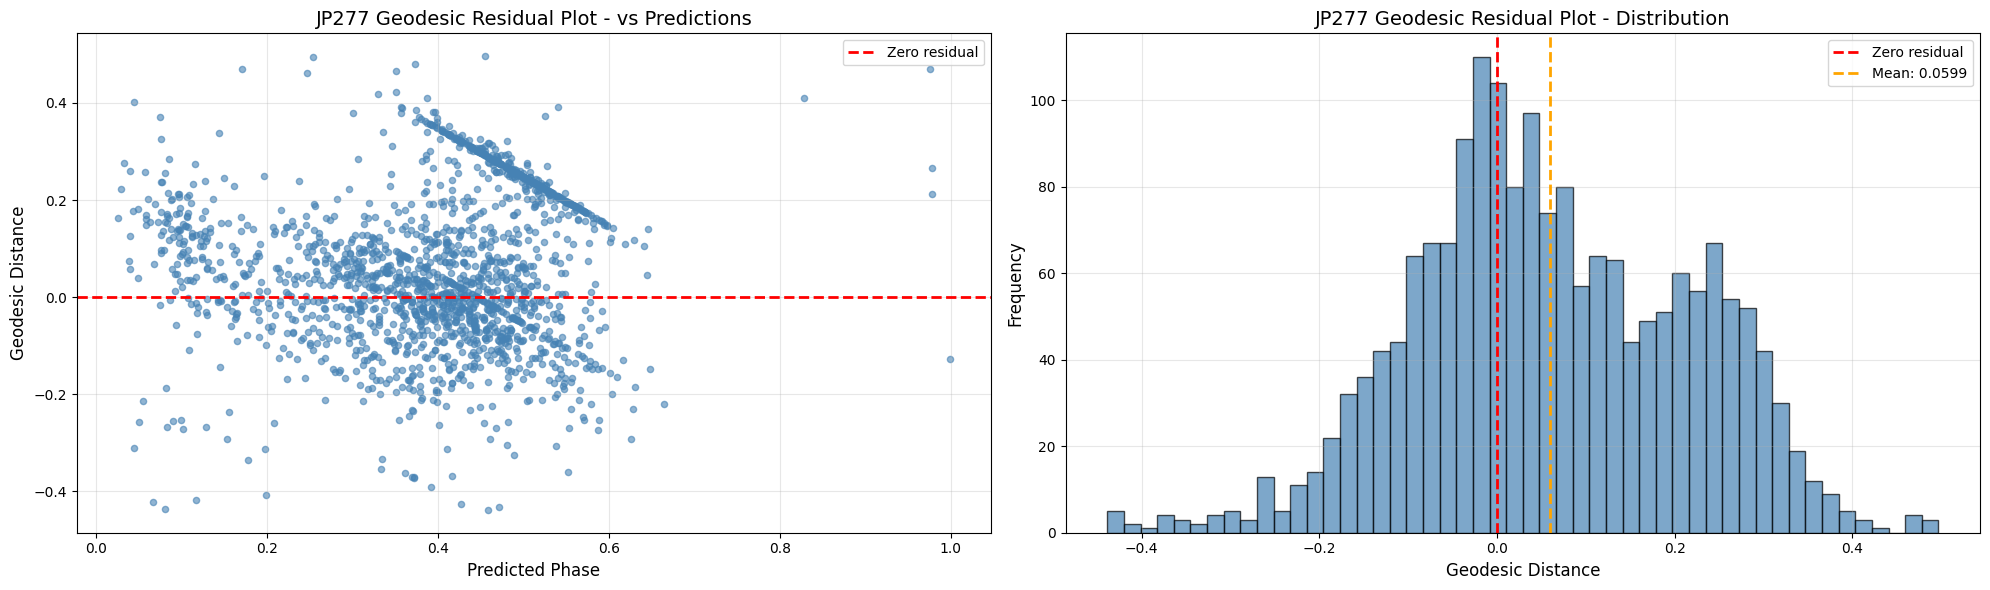

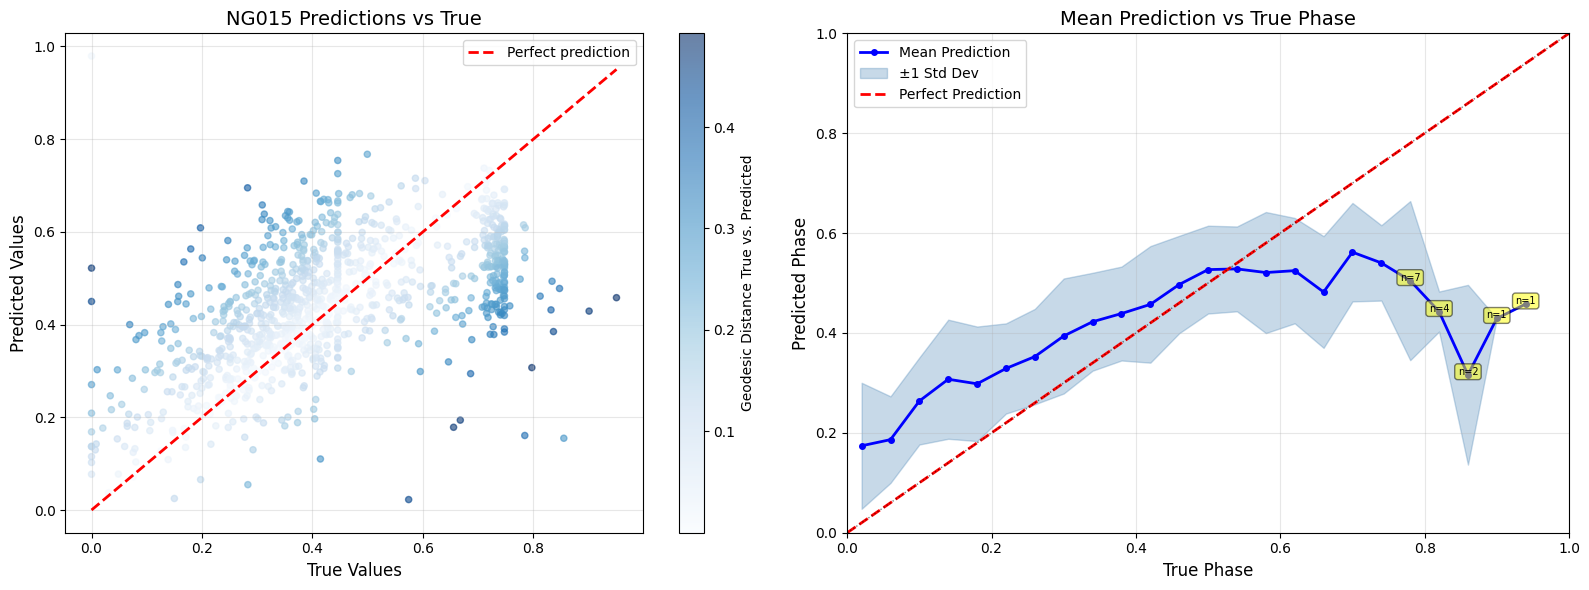

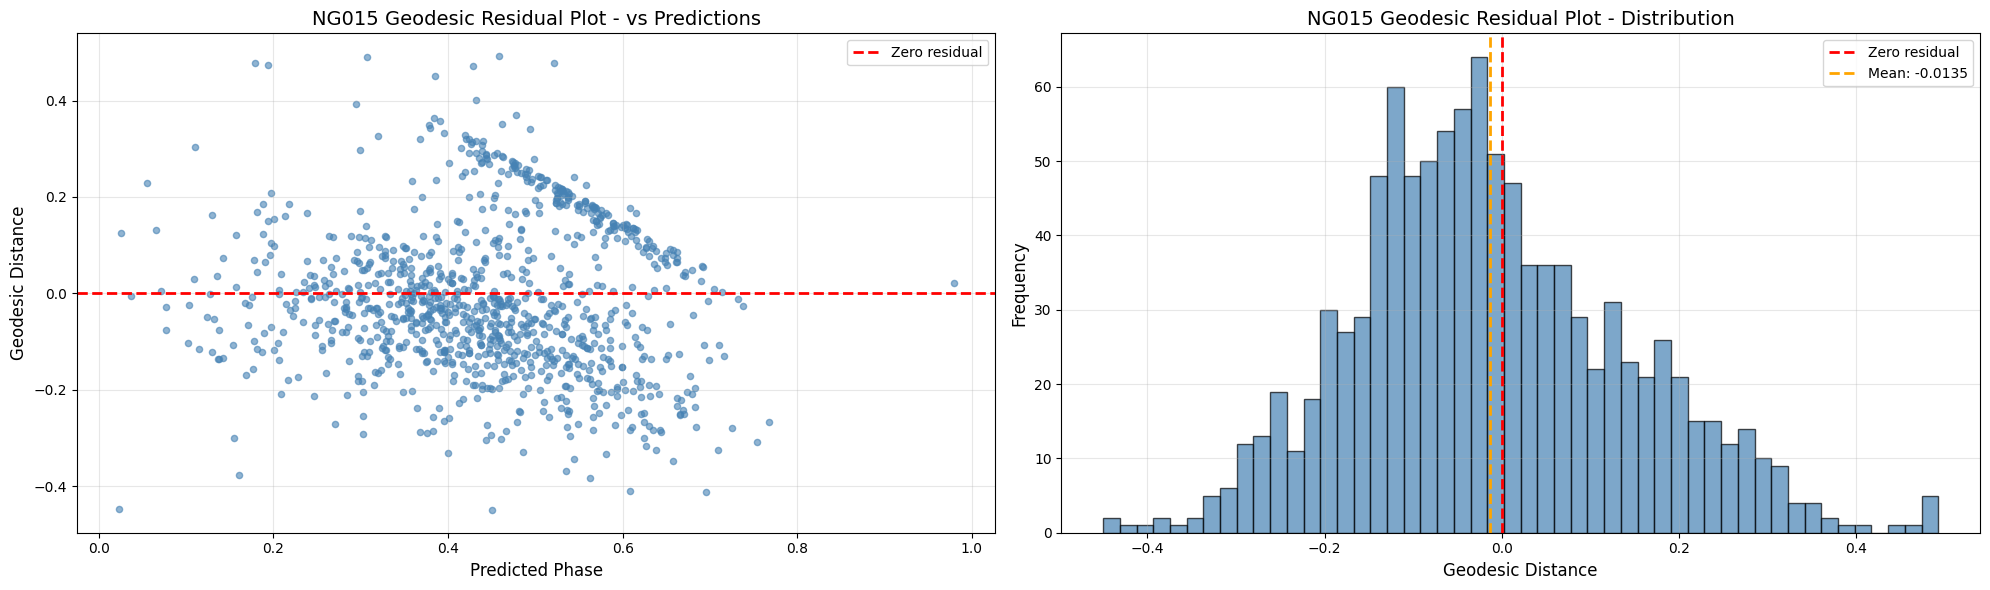

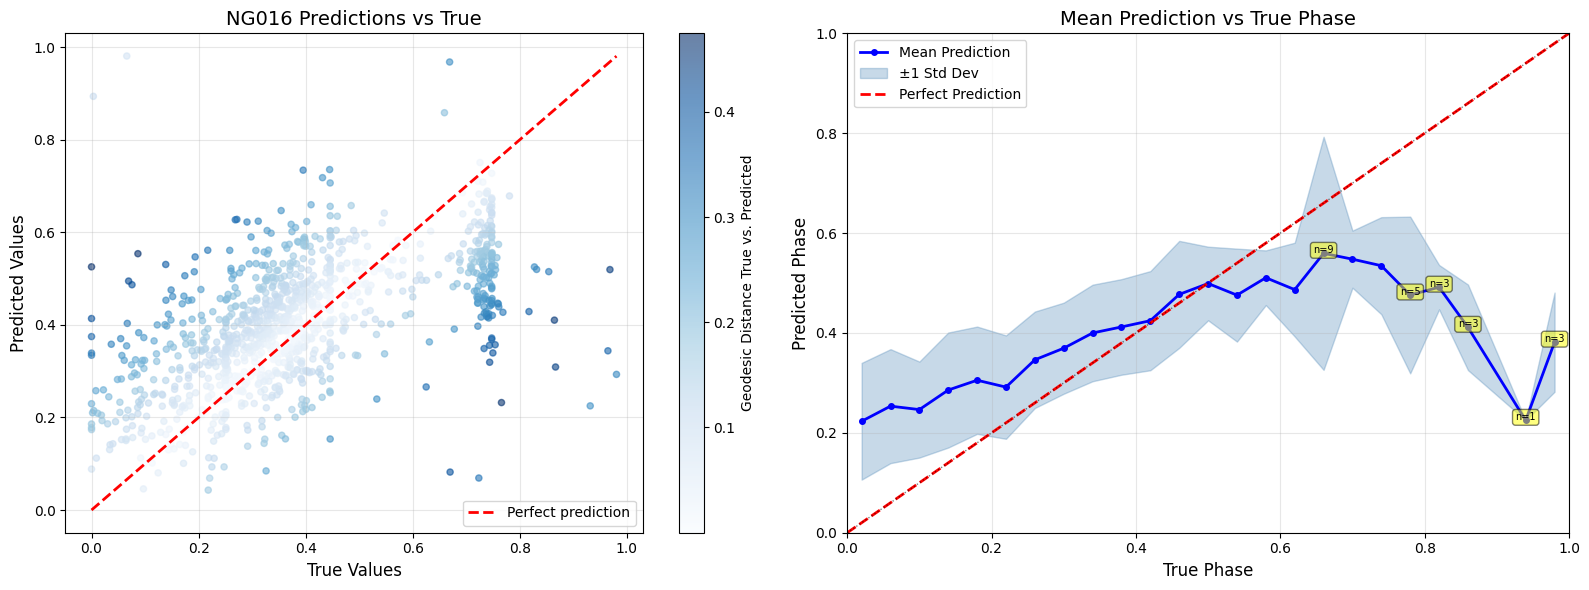

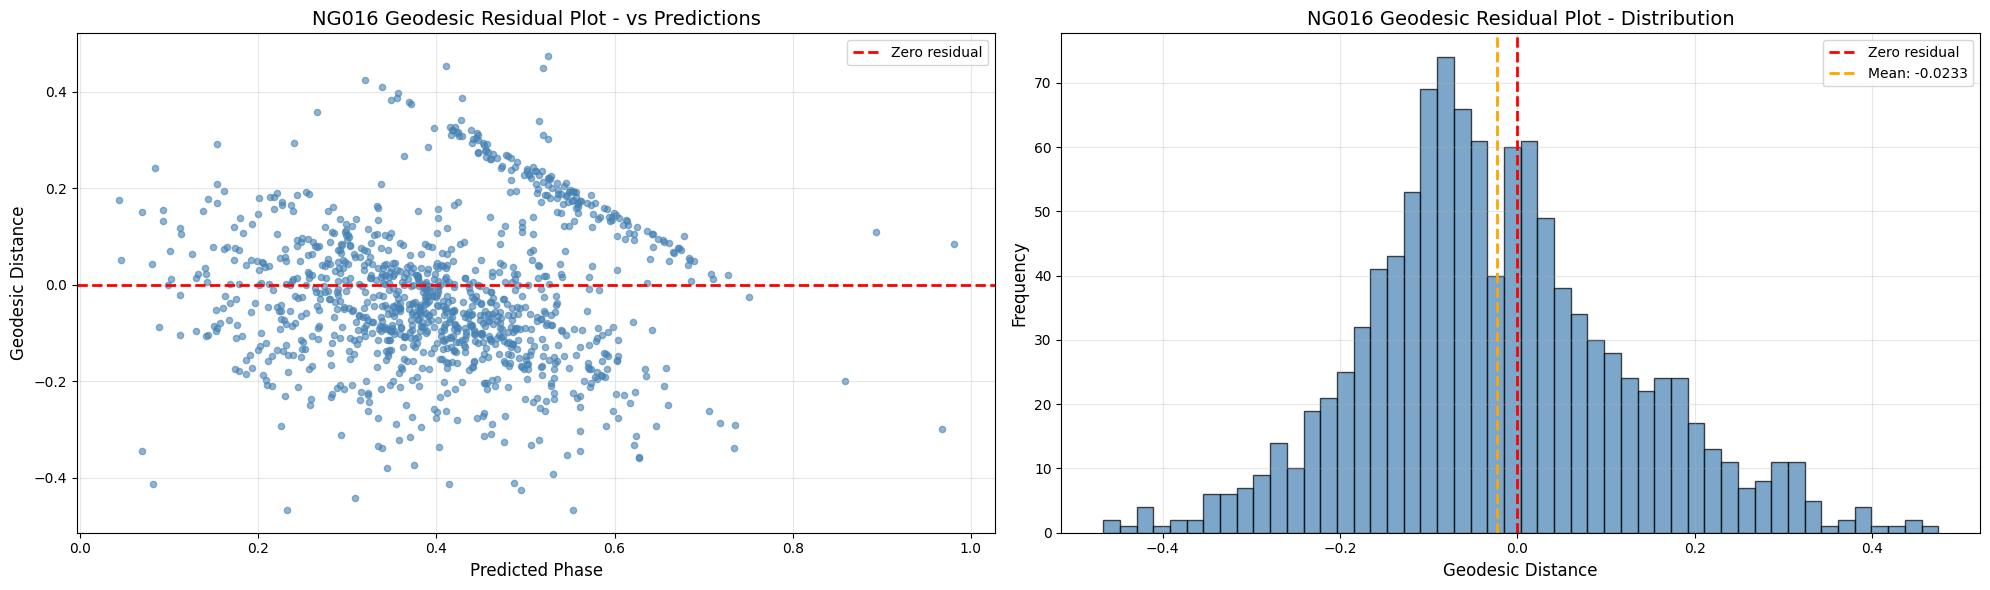

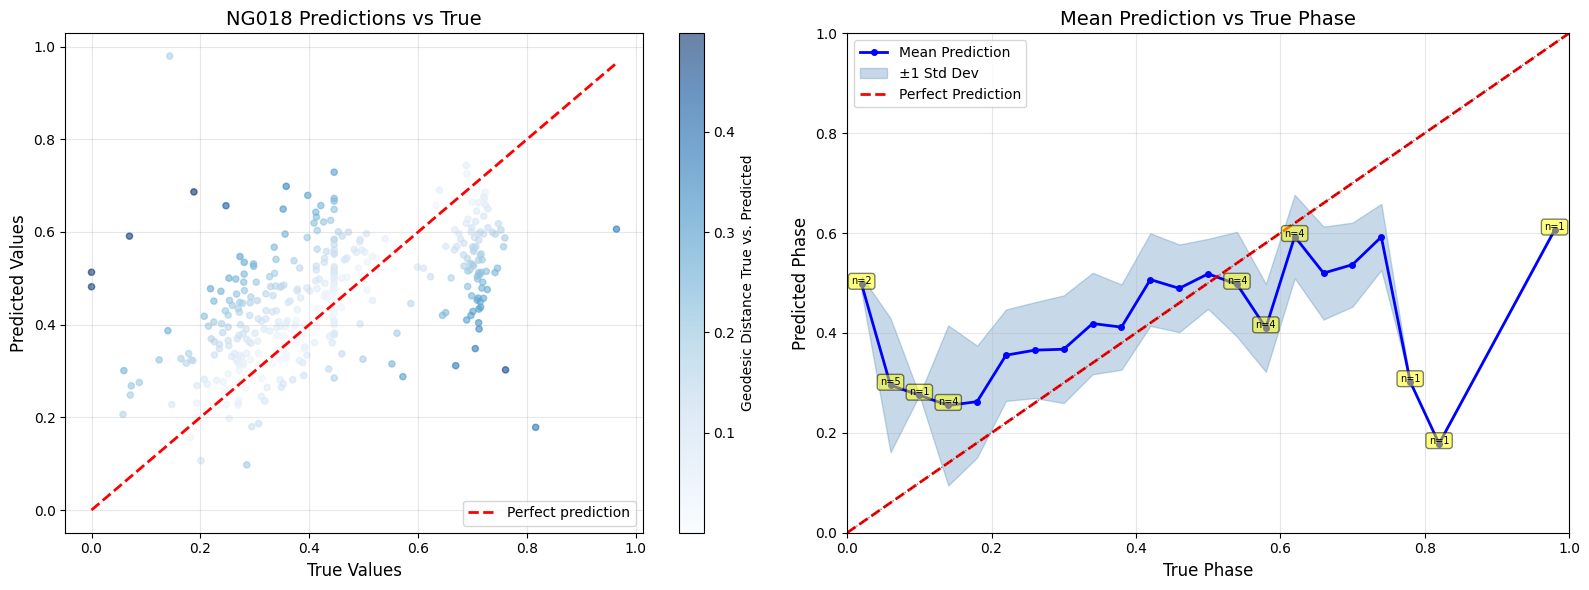

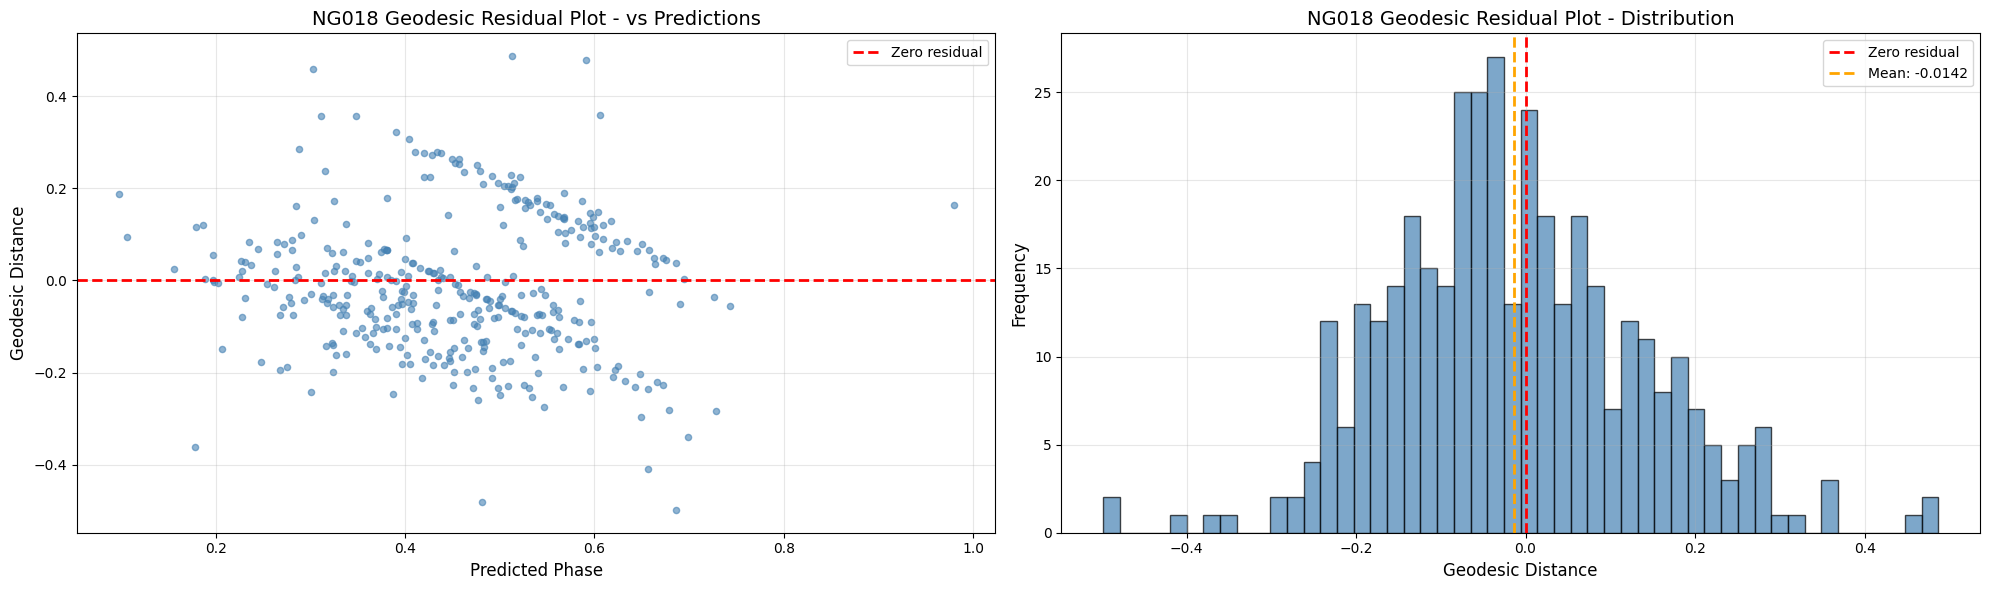

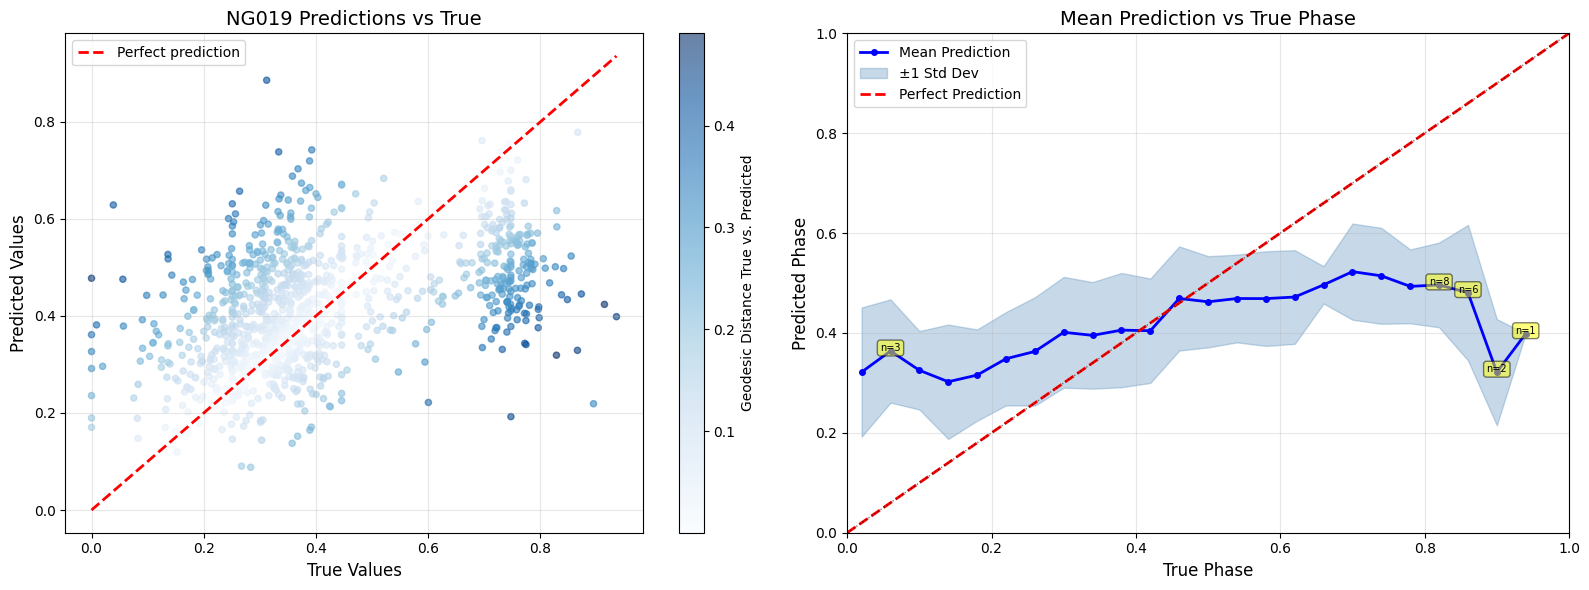

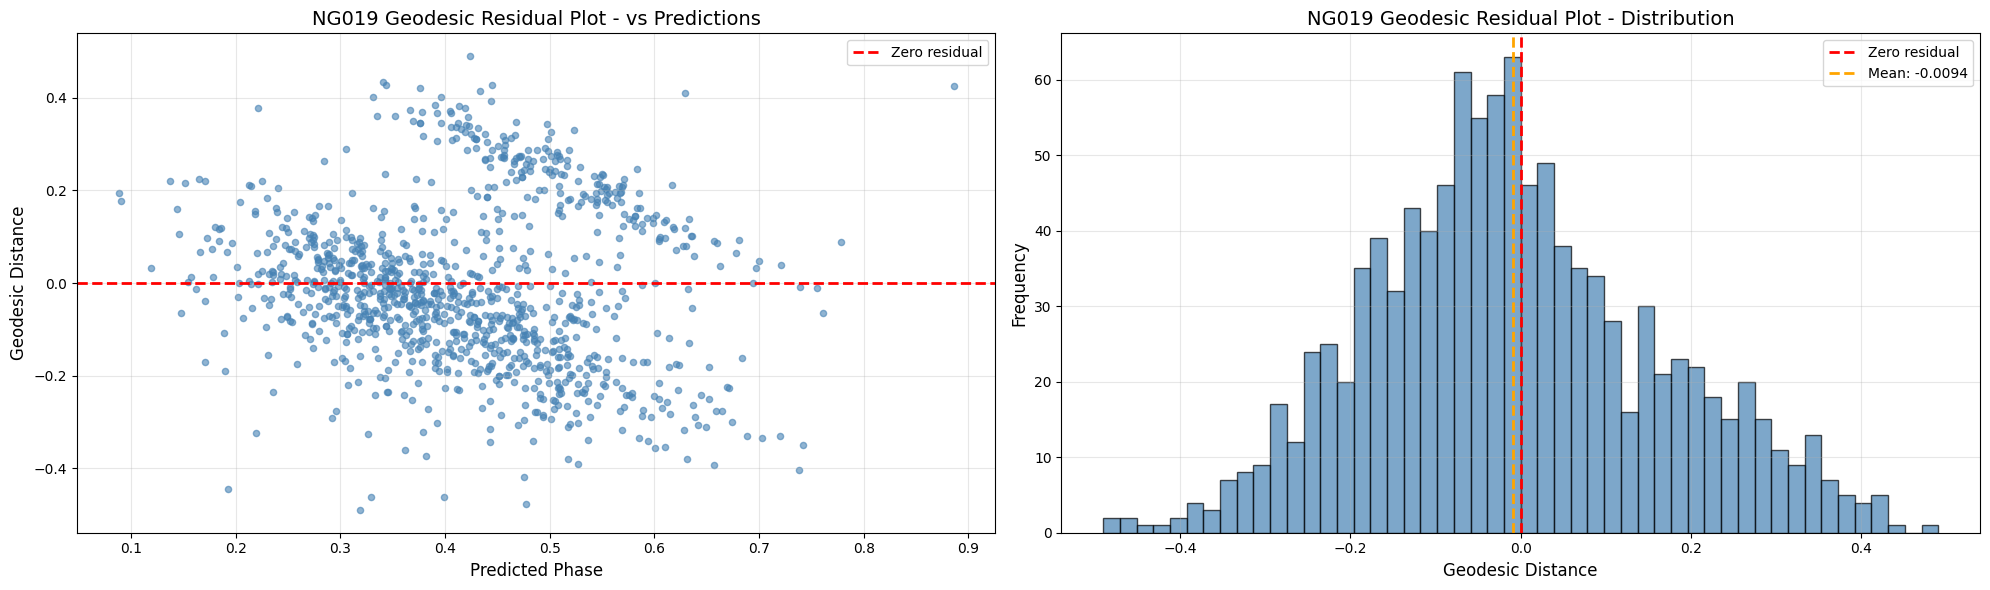

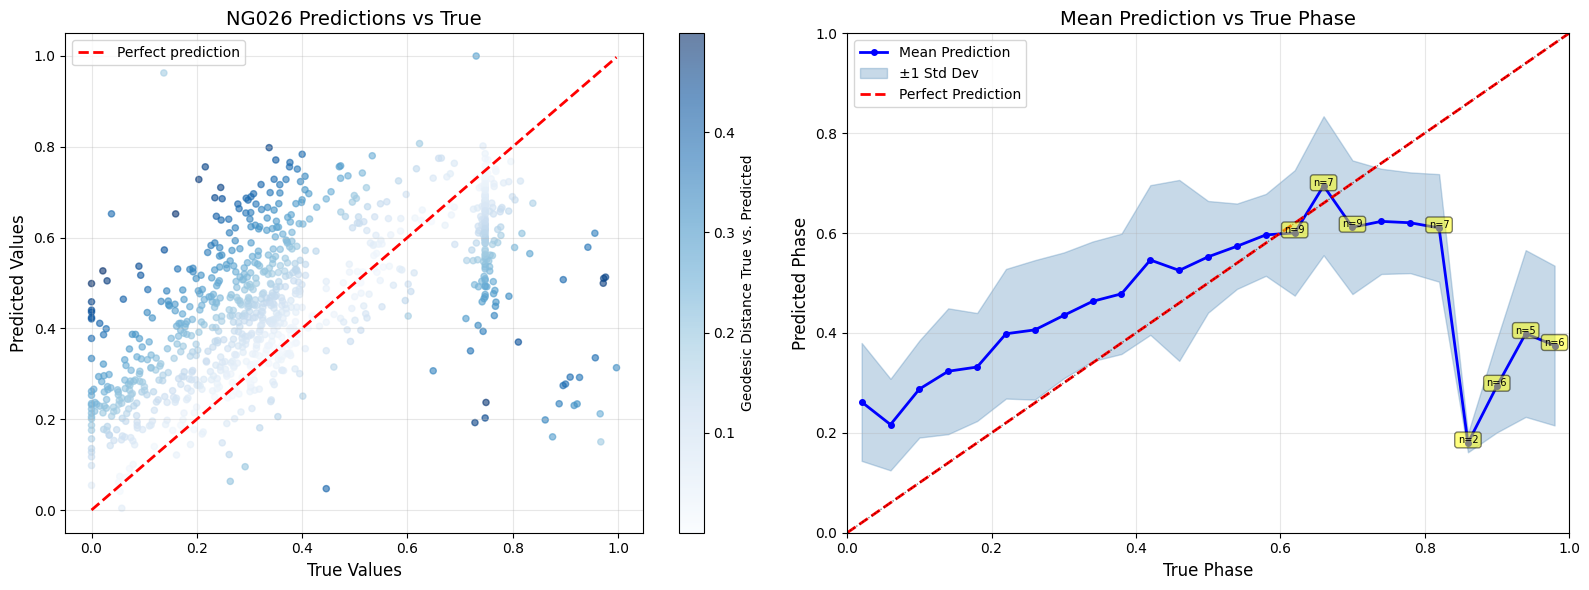

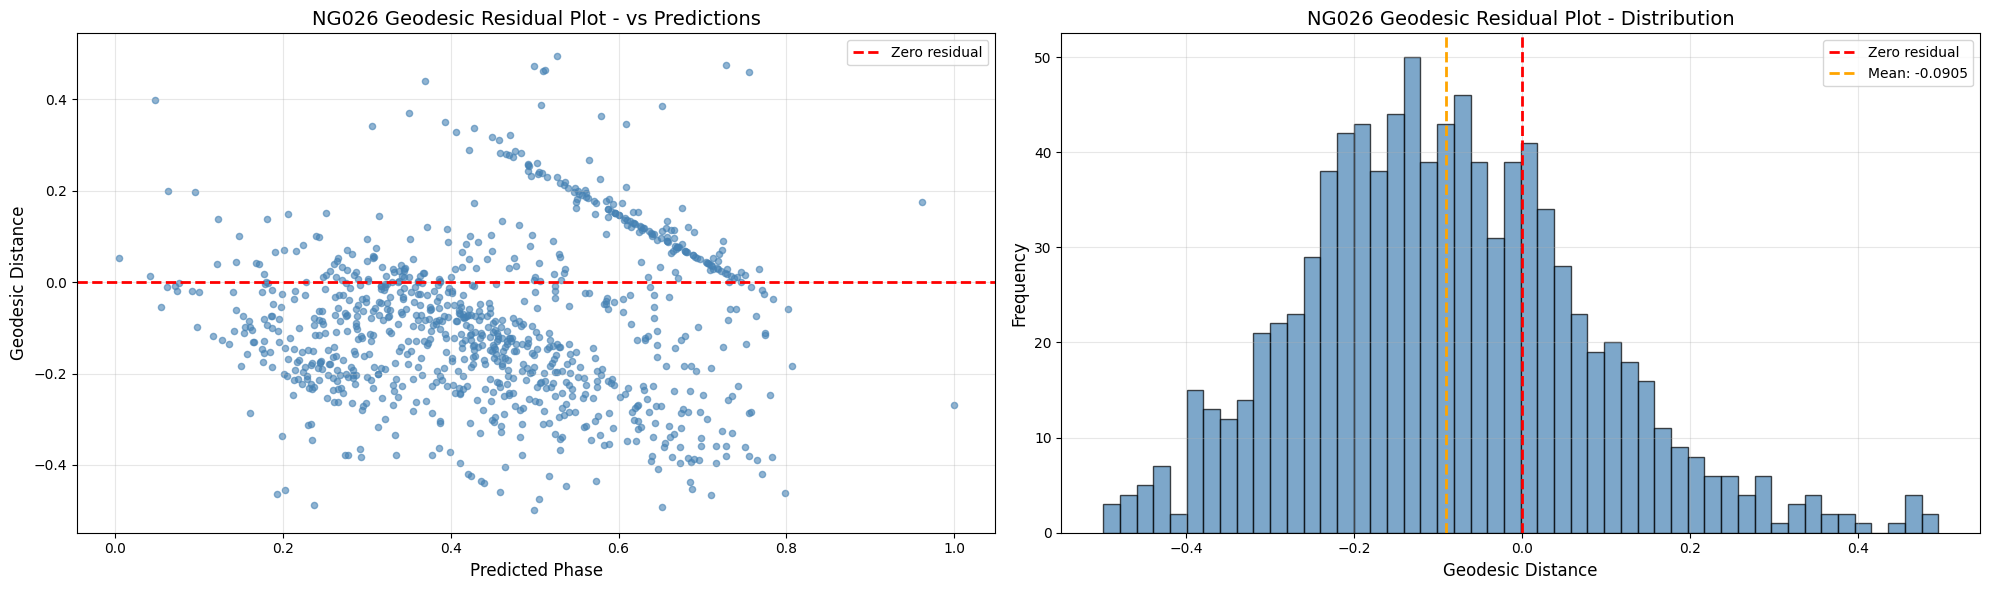

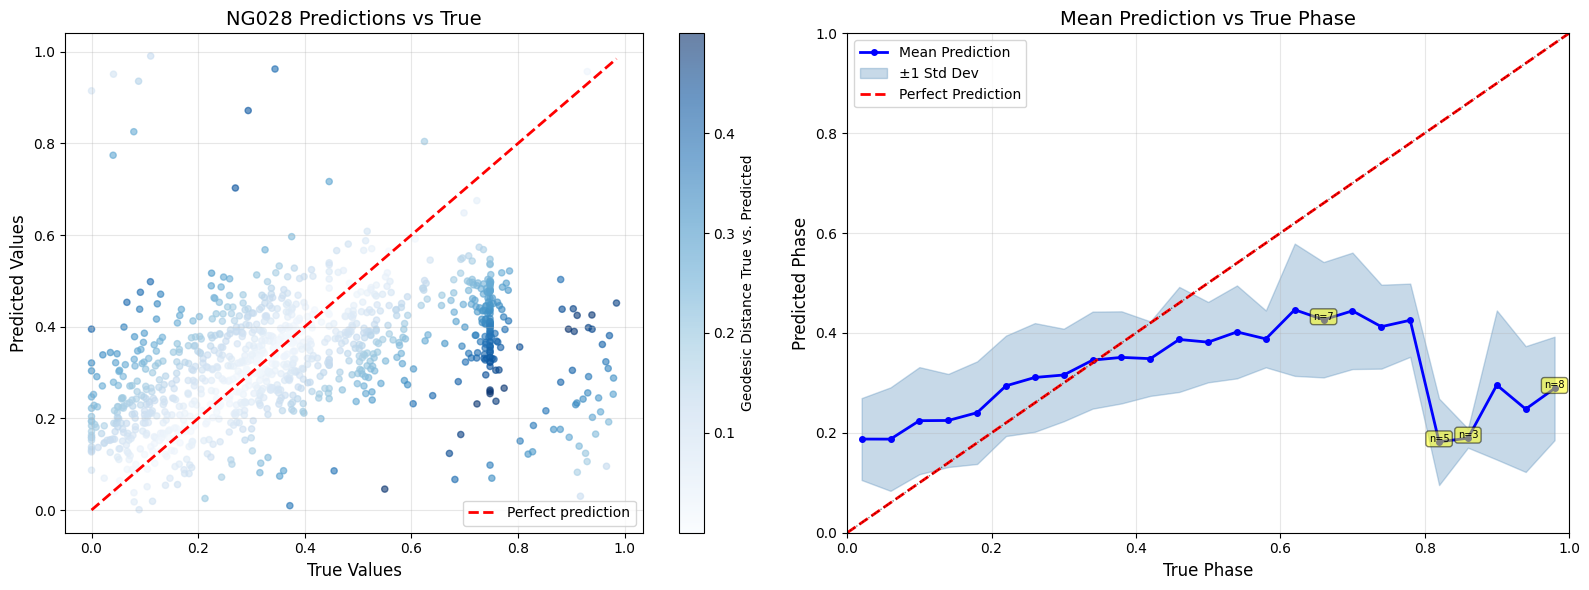

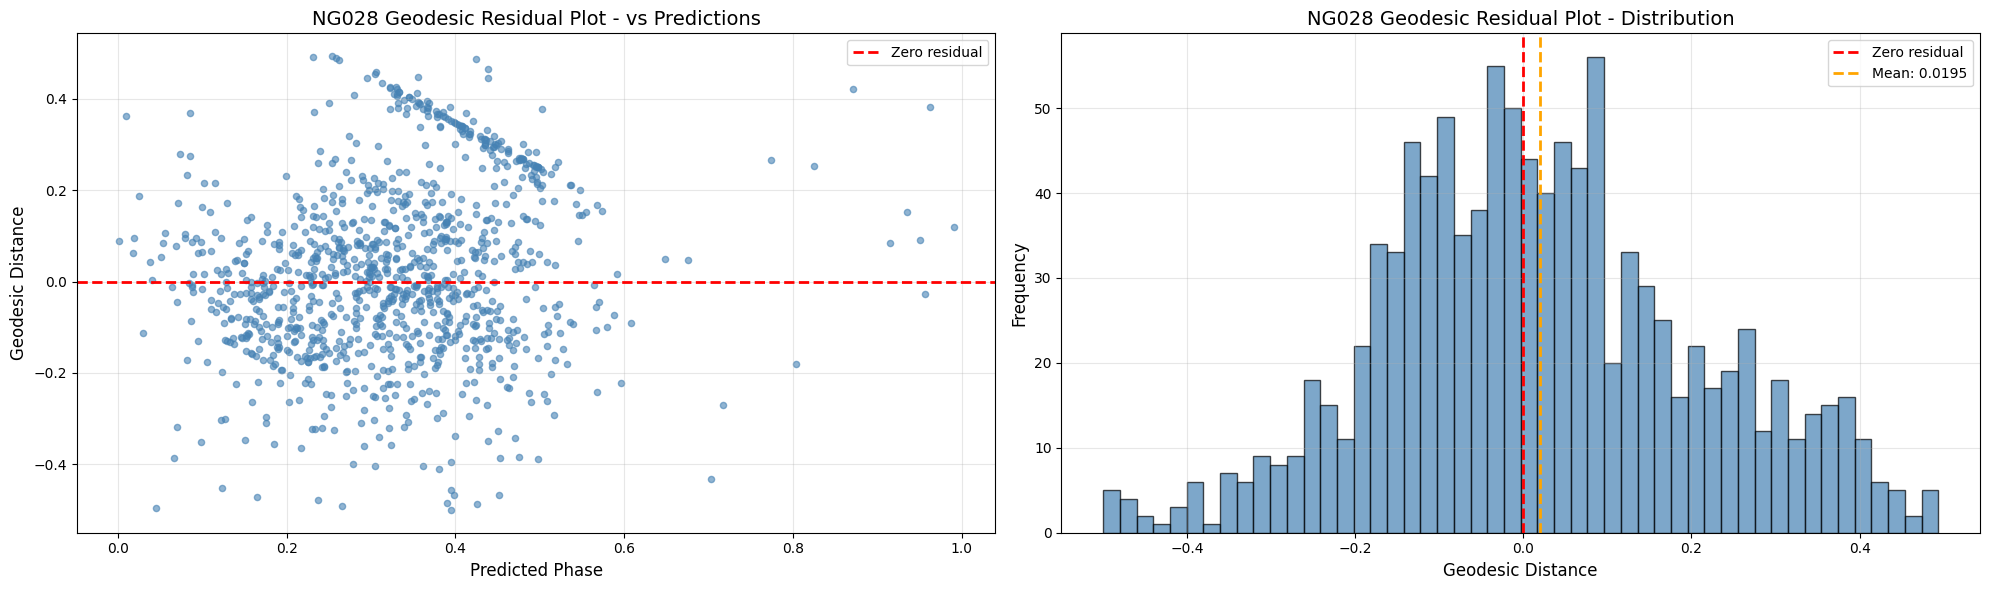

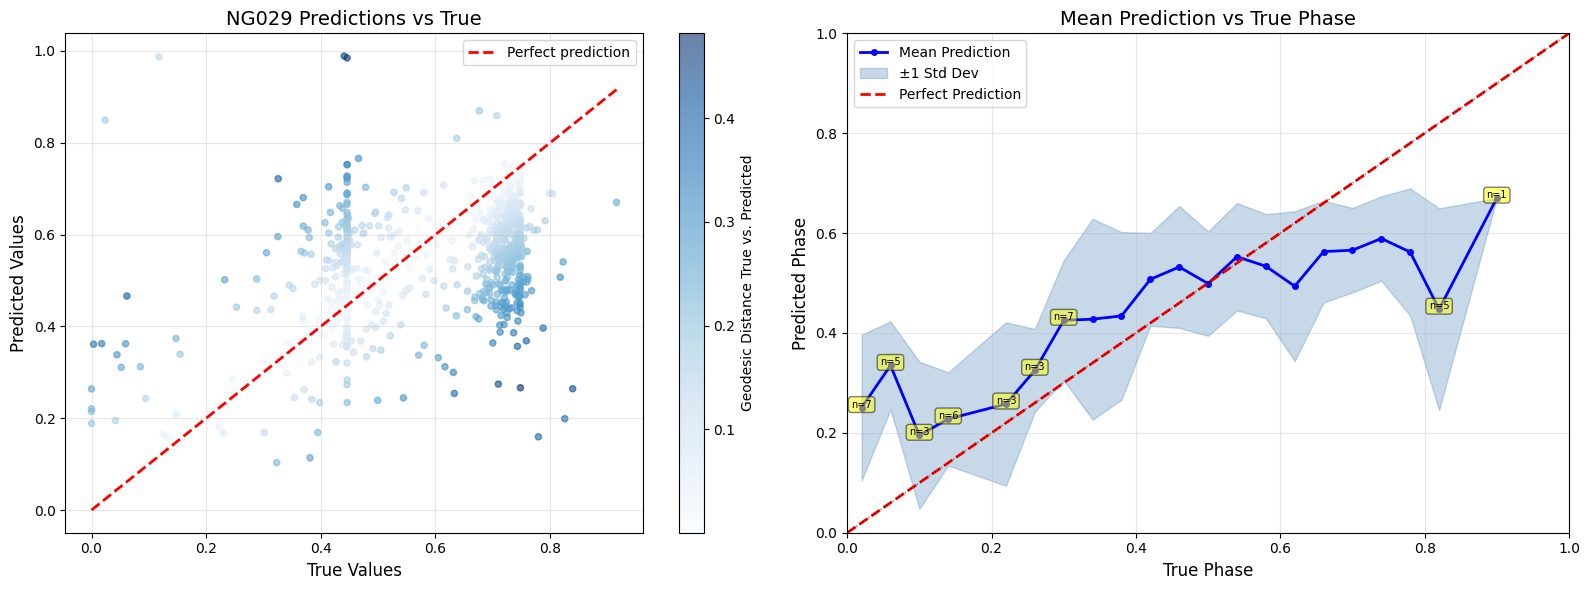

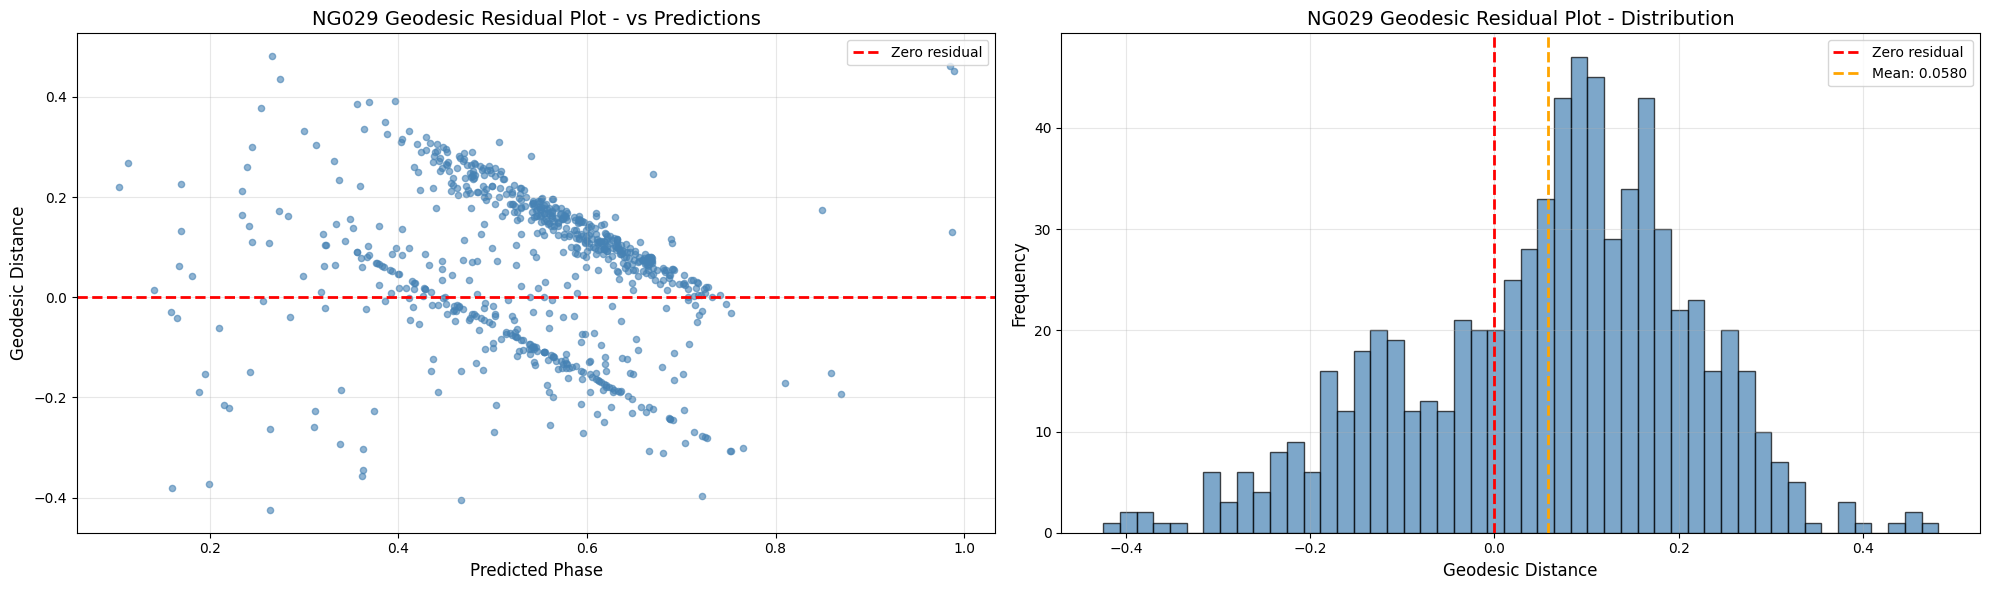

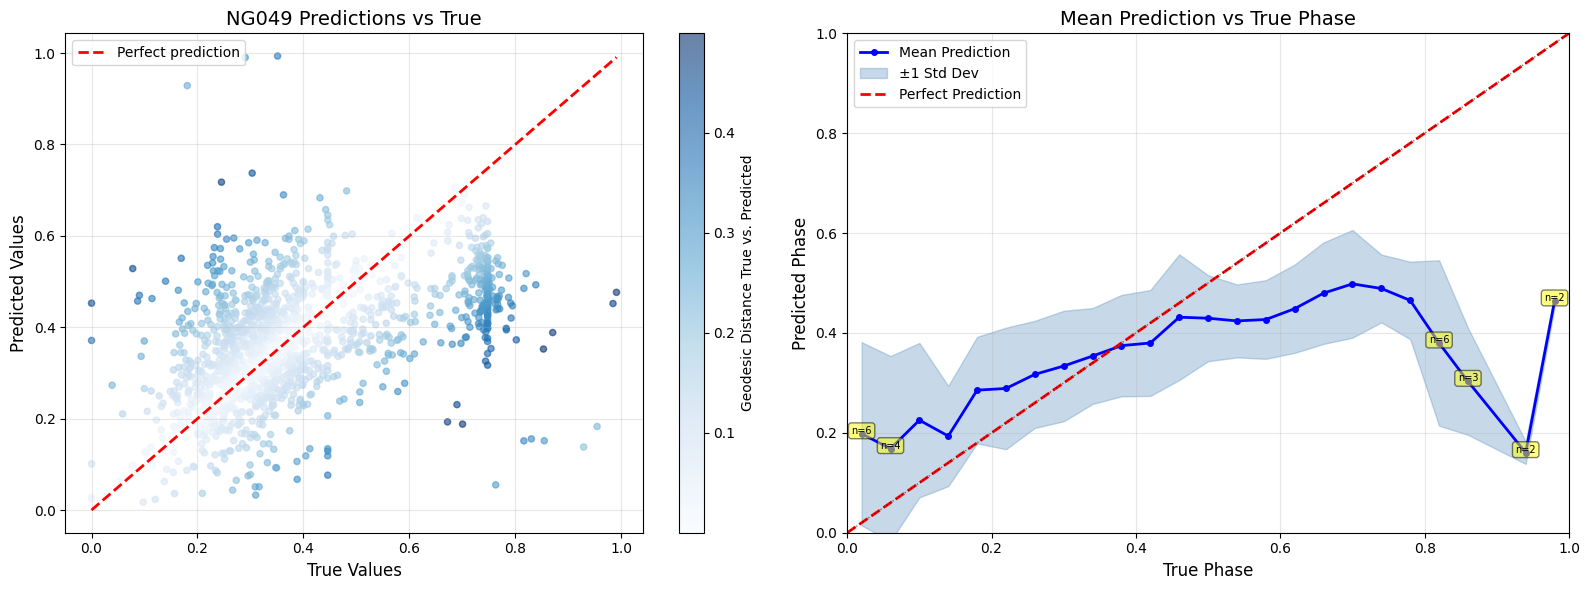

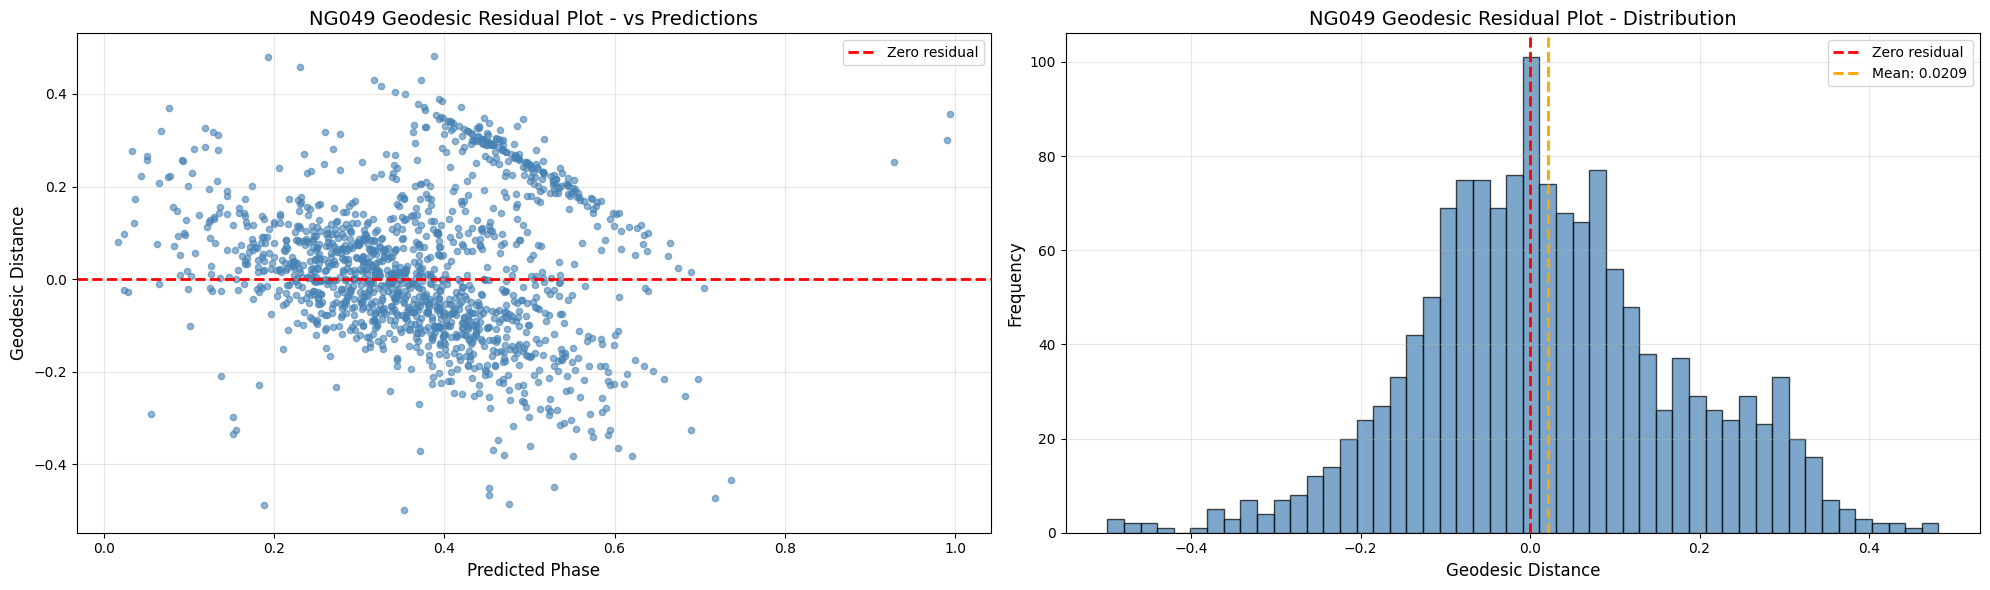

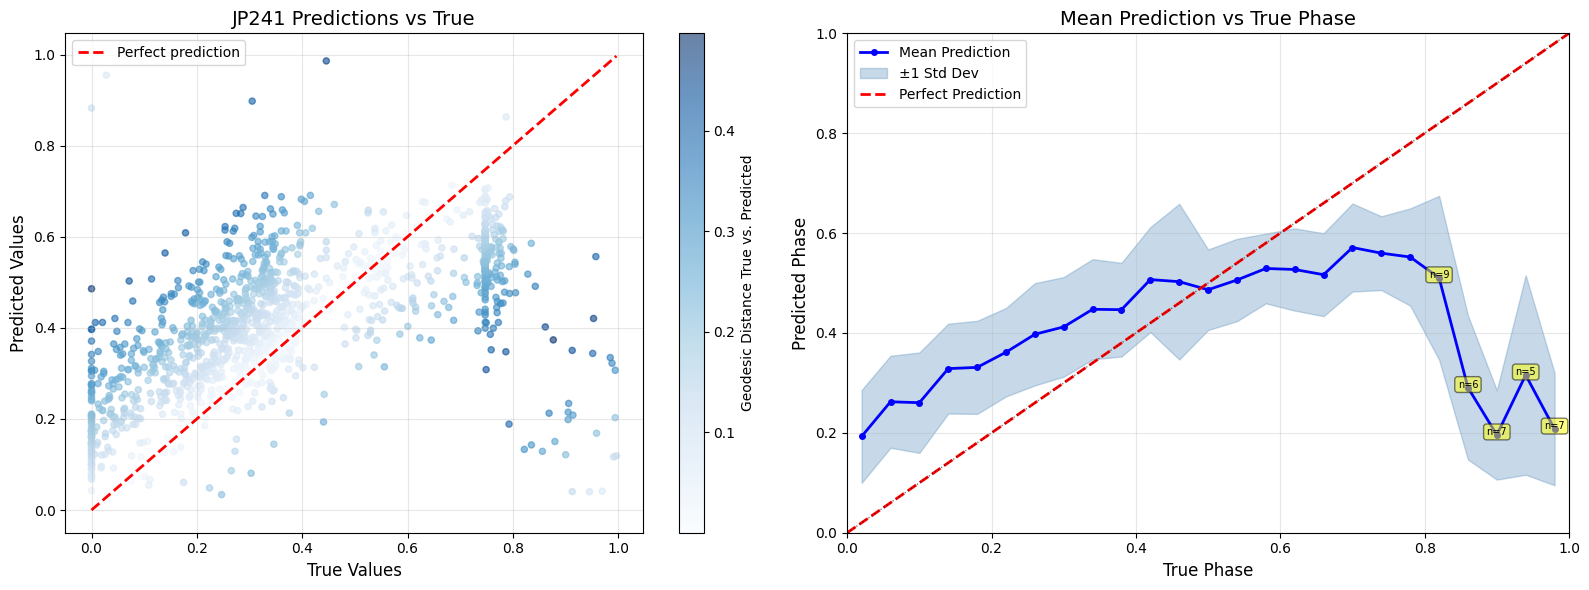

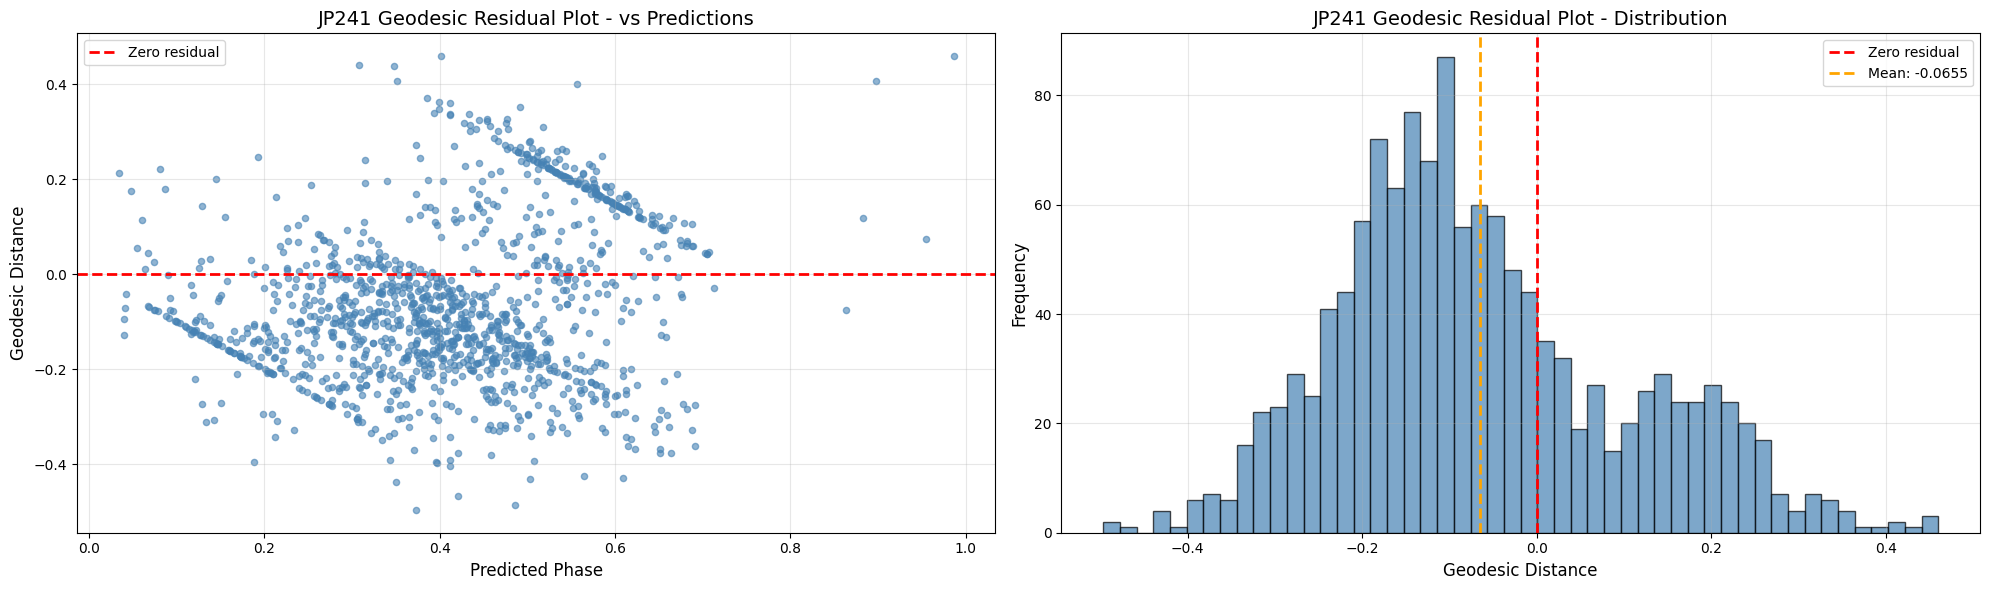

In [15]:
"""
Run leave-one-experiment-out cross-validation.
"""
print("=" * 80)
print("CROSS-VALIDATION: LEAVE-ONE-EXPERIMENT-OUT")
print("=" * 80)

cv_results = []
cv_kappas = []

for split in tqdm(exp_id_cv_splits, desc="Cross-validation"):
    model_cv, results, kappas = train_linear_model(**split, verbose=False)
    
    cv_results.append({
        'exp_id': split['exp_id'],
        'n_train': len(split['train_df']),
        'n_val': len(split['val_df']),
        'n_test': len(split['test_df']),
        'geodesic_mae': results.metrics.geodesic_mae,
        'geodesic_rmse': results.metrics.geodesic_rmse,
        'geodesic_r2': results.metrics.geodesic_r2,
        'geodesic_mse': results.metrics.geodesic_mse,
    })
    
    if kappas is not None:
        cv_kappas.append({
            'exp_id': split['exp_id'],
            'mean_kappa': np.mean(kappas),
            'std_kappa': np.std(kappas),
        })

cv_df = pd.DataFrame(cv_results)

print("\n" + "=" * 80)
print("CROSS-VALIDATION RESULTS BY EXPERIMENT")
print("=" * 80)
print(cv_df.to_string(index=False))


AGGREGATED METRICS

Metric               Weighted Avg    Simple Avg      Weighted Std   
-----------------------------------------------------------------
Geodesic MAE         0.1327          0.1341          0.0114
Geodesic RMSE        0.1666          0.1671          0.0114
Geodesic MSE         0.0279          0.0281          -
Geodesic R²          0.3777          0.3316          0.1257

Total samples: 16759
Number of folds: 12


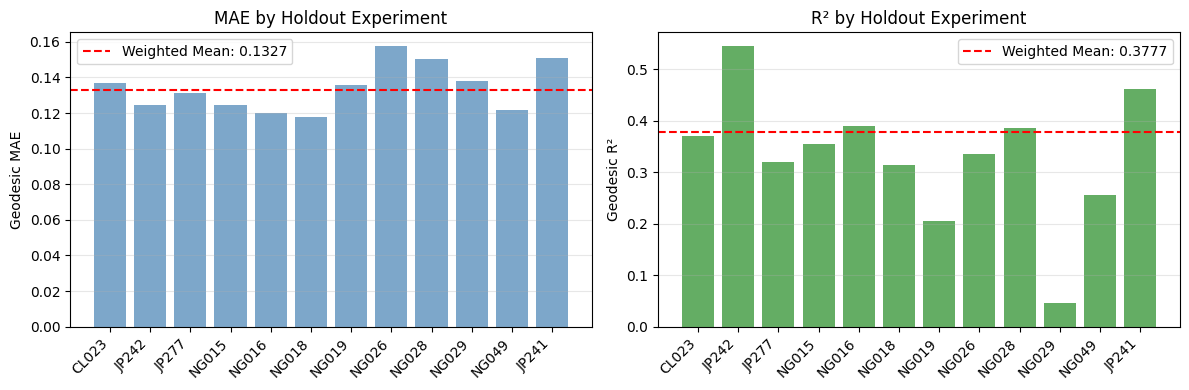

In [16]:
"""
Compute weighted and unweighted averages across CV folds.
"""
# Compute weighted averages
total_test_samples = cv_df['n_test'].sum()
weights = cv_df['n_test'] / total_test_samples

weighted_mae = (cv_df['geodesic_mae'] * weights).sum()
weighted_rmse = (cv_df['geodesic_rmse'] * weights).sum()
weighted_r2 = (cv_df['geodesic_r2'] * weights).sum()
weighted_mse = (cv_df['geodesic_mse'] * weights).sum()

# Simple averages
simple_mae = cv_df['geodesic_mae'].mean()
simple_rmse = cv_df['geodesic_rmse'].mean()
simple_r2 = cv_df['geodesic_r2'].mean()
simple_mse = cv_df['geodesic_mse'].mean()

# Weighted std
weighted_std_mae = np.sqrt((weights * (cv_df['geodesic_mae'] - weighted_mae)**2).sum())
weighted_std_rmse = np.sqrt((weights * (cv_df['geodesic_rmse'] - weighted_rmse)**2).sum())
weighted_std_r2 = np.sqrt((weights * (cv_df['geodesic_r2'] - weighted_r2)**2).sum())

print("\n" + "=" * 80)
print("AGGREGATED METRICS")
print("=" * 80)
print(f"\n{'Metric':<20} {'Weighted Avg':<15} {'Simple Avg':<15} {'Weighted Std':<15}")
print("-" * 65)
print(f"{'Geodesic MAE':<20} {weighted_mae:.4f}          {simple_mae:.4f}          {weighted_std_mae:.4f}")
print(f"{'Geodesic RMSE':<20} {weighted_rmse:.4f}          {simple_rmse:.4f}          {weighted_std_rmse:.4f}")
print(f"{'Geodesic MSE':<20} {weighted_mse:.4f}          {simple_mse:.4f}          -")
print(f"{'Geodesic R²':<20} {weighted_r2:.4f}          {simple_r2:.4f}          {weighted_std_r2:.4f}")

print(f"\nTotal samples: {total_test_samples}")
print(f"Number of folds: {len(cv_df)}")

# Plot CV results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = range(len(cv_df))
ax.bar(x, cv_df['geodesic_mae'], color='steelblue', alpha=0.7)
ax.axhline(weighted_mae, color='red', linestyle='--', label=f'Weighted Mean: {weighted_mae:.4f}')
ax.set_xticks(x)
ax.set_xticklabels(cv_df['exp_id'], rotation=45, ha='right')
ax.set_ylabel('Geodesic MAE')
ax.set_title('MAE by Holdout Experiment')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x, cv_df['geodesic_r2'], color='forestgreen', alpha=0.7)
ax.axhline(weighted_r2, color='red', linestyle='--', label=f'Weighted Mean: {weighted_r2:.4f}')
ax.set_xticks(x)
ax.set_xticklabels(cv_df['exp_id'], rotation=45, ha='right')
ax.set_ylabel('Geodesic R²')
ax.set_title('R² by Holdout Experiment')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Feature Importance (Model Weights)

TOP 20 FEATURES BY MODEL WEIGHT

Rank  Feature                                       Weight       |Weight|    
---------------------------------------------------------------------------
1     cell_area^2                                   -0.1452      0.1452      
2     total_intensity_nucleus                       0.1414       0.1414      
3     cell_nucleus_area_ratio                       0.1196       0.1196      
4     cell_minor_axis_length^2                      0.1138       0.1138      
5     nucleus_perimeter                             -0.1033      0.1033      
6     cell_perimeter^2                              0.0980       0.0980      
7     cell_minor_axis_length                        0.0957       0.0957      
8     nucleus_solidity                              0.0929       0.0929      
9     nucleus_solidity^2                            -0.0923      0.0923      
10    haralick_correlation_nucleus^2                0.0744       0.0744      
11    haralick_correlation_nucleu

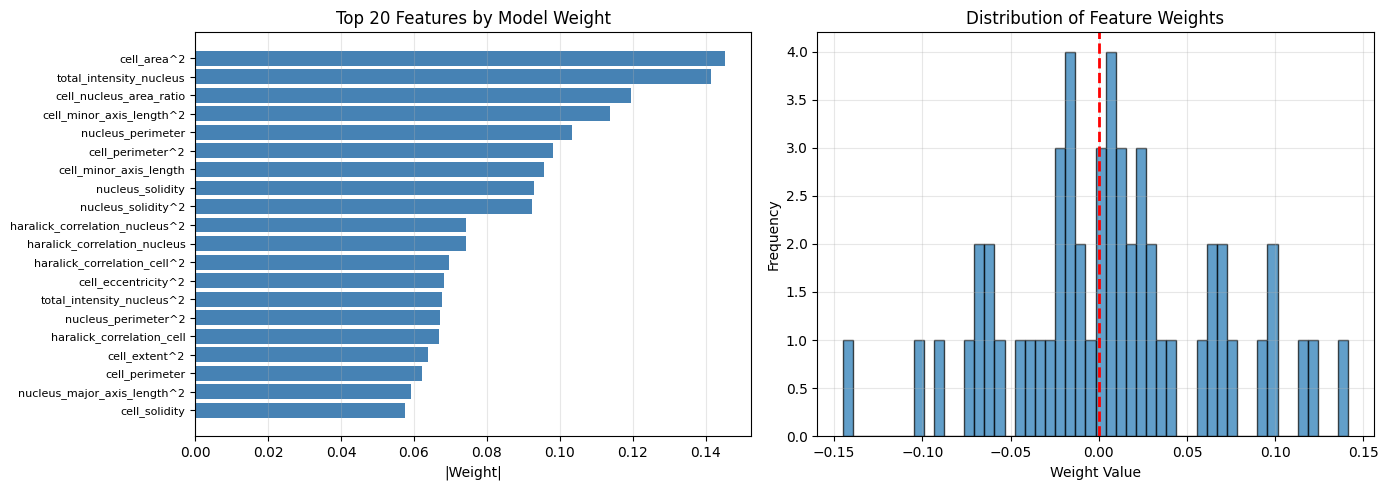

In [21]:
"""
Analyze feature importance from model weights.
"""
# Get weights from full model
weights = model_trained.linear.weight.detach().cpu().numpy().squeeze()
bias = model_trained.linear.bias.detach().cpu().item()
# Feature importance
feature_importance = np.abs(weights)
sorted_indices = np.argsort(feature_importance)[::-1]

print("=" * 80)
print("TOP 20 FEATURES BY MODEL WEIGHT")
print("=" * 80)
print(f"\n{'Rank':<5} {'Feature':<45} {'Weight':<12} {'|Weight|':<12}")
print("-" * 75)
for i in range(min(20, len(sorted_indices))):
    idx = sorted_indices[i]
    print(f"{i+1:<5} {all_feature_cols[idx]:<45} {weights[idx]:<12.4f} {feature_importance[idx]:<12.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
top_k = 20
ax.barh(range(top_k), feature_importance[sorted_indices[:top_k]][::-1], color='steelblue')
ax.set_yticks(range(top_k))
ax.set_yticklabels([all_feature_cols[i] for i in sorted_indices[:top_k]][::-1], fontsize=8)
ax.set_xlabel('|Weight|')
ax.set_title(f'Top {top_k} Features by Model Weight')
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
ax.hist(weights, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Weight Value')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Feature Weights')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. SHAP Feature Importance Analysis

In [12]:
"""
SHAP analysis for linear regression model.
"""
import shap

print("=" * 80)
print("SHAP FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Prepare data
X_train_np = train_df_no_exp[all_feature_cols].values
X_val_np = val_df_no_exp[all_feature_cols].values

# Create prediction function
def model_predict(X):
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        return (model_trained(X_tensor) % 1.0).cpu().numpy()

# Sample background data
n_background = min(500, len(X_train_np))
background_indices = np.random.choice(len(X_train_np), n_background, replace=False)
X_background = X_train_np[background_indices]

print("Creating SHAP KernelExplainer...")
explainer = shap.KernelExplainer(model_predict, X_background)


Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


SHAP FEATURE IMPORTANCE ANALYSIS
Creating SHAP KernelExplainer...


SHAP FEATURE IMPORTANCE vs CELL CYCLE PHASE


Computing SHAP by phase:   0%|          | 0/5 [00:00<?, ?it/s]

  Computing SHAP for phase 0.00-0.20 (150 samples)...


  0%|          | 0/150 [00:00<?, ?it/s]

Computing SHAP by phase:  20%|██        | 1/5 [01:48<07:15, 108.75s/it]

...

Computing SHAP by phase:  80%|████████  | 4/5 [07:07<01:46, 106.72s/it]

  Computing SHAP for phase 0.80-1.00 (8 samples)...


  0%|          | 0/8 [00:00<?, ?it/s]

Computing SHAP by phase: 100%|██████████| 5/5 [07:13<00:00, 86.69s/it] 



TOP 15 FEATURES (by average SHAP across all phases)
1 total_intensity_nucleus 0.04977248828105405
2 cell_minor_axis_length^2 0.03843307664172838
3 cell_minor_axis_length 0.03243760739116148
4 cell_perimeter^2 0.028681690583761653
5 cell_nucleus_area_ratio 0.02059528328145138
6 haralick_correlation_cell 0.019428604960768342
7 haralick_correlation_nucleus^2 0.017774968009406172
8 cell_area^2 0.017440355702638733
9 nucleus_perimeter 0.016574374248657892
10 cell_eccentricity^2 0.014993668765684883
11 nucleus_perimeter^2 0.014531634040705371
12 haralick_correlation_cell^2 0.012130114864485383
13 haralick_correlation_nucleus 0.012124554288295501
14 cell_extent^2 0.01062637396217377
15 nucleus_solidity 0.00911628743497087
16 haralick_entropy_cell 0.008682937861734012
17 nucleus_solidity^2 0.008533076286633573
18 cell_perimeter 0.006112349047498759
19 haralick_entropy_nucleus 0.005986553621887513
20 nucleus_major_axis_length 0.005362482207167074
21 nucleus_major_axis_length^2 0.00497020326366

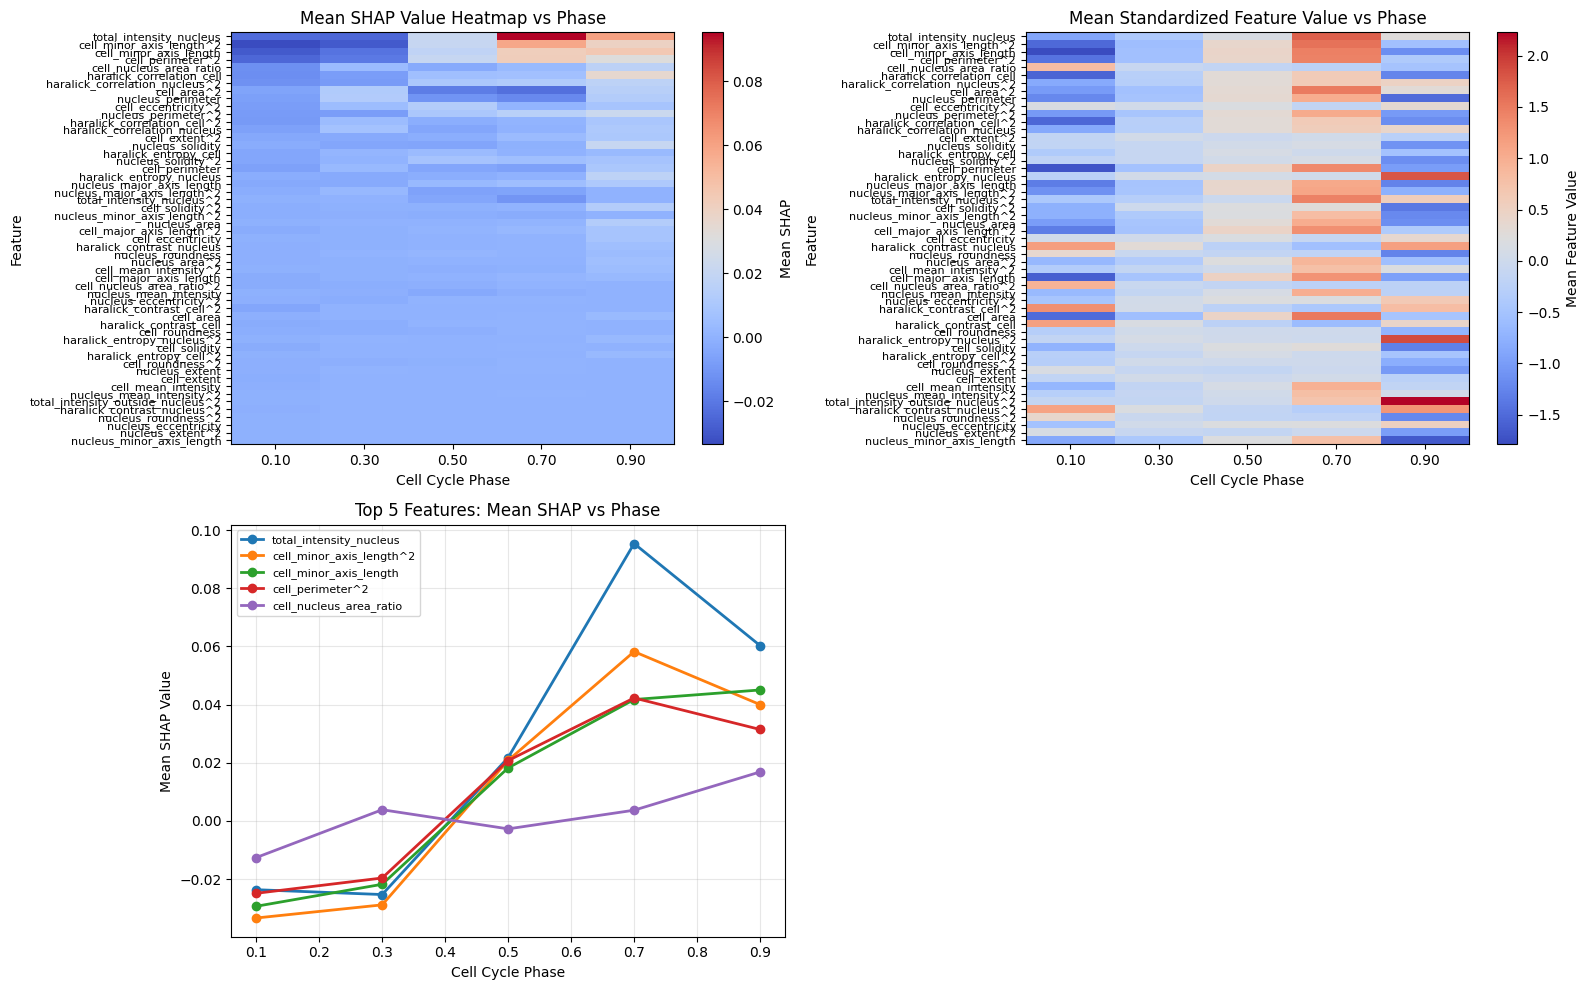


Interpretation:
- High std dev → Feature importance changes significantly across cell cycle
- Positive SHAP → Feature pushes prediction toward later phases
- Negative SHAP → Feature pushes prediction toward earlier phases


In [13]:
"""
SHAP Feature Importance vs Cell Cycle Phase
"""
print("=" * 80)
print("SHAP FEATURE IMPORTANCE vs CELL CYCLE PHASE")
print("=" * 80)

# Get predictions for phase binning
val_predictions = model_predict(X_val_np)

# Define phase bins
n_phase_bins = 5
phase_bins = np.linspace(0, 1, n_phase_bins + 1)
phase_labels = [f"{phase_bins[i]:.2f}-{phase_bins[i+1]:.2f}" for i in range(n_phase_bins)]

# Compute SHAP values for each phase bin
shap_by_phase = []
phase_bin_centers = []
abs_shap_by_phase = []
mean_feature_values = []

for i in tqdm(range(n_phase_bins), desc="Computing SHAP by phase"):
    phase_mask = (val_predictions.flatten() >= phase_bins[i]) & \
                 (val_predictions.flatten() < phase_bins[i+1])
    
    n_samples_bin = min(150, phase_mask.sum())
    bin_indices = np.where(phase_mask)[0]
    np.random.shuffle(bin_indices)
    bin_indices = bin_indices[:n_samples_bin]
    
    X_bin = X_val_np[bin_indices]
    mean_feature_values.append(X_bin.mean(axis=0))
    
    print(f"  Computing SHAP for phase {phase_labels[i]} ({len(X_bin)} samples)...")
    shap_values_bin = explainer.shap_values(X_bin)
    
    mean_abs_shap_bin = np.abs(shap_values_bin).mean(axis=0)
    mean_shap_bin = shap_values_bin.mean(axis=0)
    abs_shap_by_phase.append(mean_abs_shap_bin)
    shap_by_phase.append(mean_shap_bin)
    phase_bin_centers.append((phase_bins[i] + phase_bins[i+1]) / 2)

shap_by_phase = np.array(shap_by_phase)

# Find top features
overall_importance = np.array(abs_shap_by_phase).mean(axis=0).squeeze()
top_feature_indices = np.argsort(overall_importance)[-53:][::-1]
top_feature_names = [all_feature_cols[int(i)] for i in top_feature_indices]

print("\n" + "=" * 80)
print("TOP 15 FEATURES (by average SHAP across all phases)")
print("=" * 80)
for i, (idx, name) in enumerate(zip(top_feature_indices, top_feature_names)):
    print(f"{i+1} {name} {overall_importance[idx]}")

# Visualize
fig = plt.figure(figsize=(16, 10))

# 1. Heatmap
ax1 = plt.subplot(2, 2, 1)
im = ax1.imshow(shap_by_phase.squeeze()[:, top_feature_indices].T, aspect='auto', cmap='coolwarm')
ax1.set_xlabel('Cell Cycle Phase')
ax1.set_ylabel('Feature')
ax1.set_xticks(range(len(phase_bin_centers)))
ax1.set_xticklabels([f"{c:.2f}" for c in phase_bin_centers])
ax1.set_yticks(range(len(top_feature_names)))
ax1.set_yticklabels(top_feature_names, fontsize=8)
ax1.set_title('Mean SHAP Value Heatmap vs Phase')
plt.colorbar(im, ax=ax1, label='Mean SHAP')

# 2. Feature values heatmap
ax2 = plt.subplot(2, 2, 2)
im = ax2.imshow(np.array(mean_feature_values)[:, top_feature_indices].T, aspect='auto', cmap='coolwarm')
ax2.set_xlabel('Cell Cycle Phase')
ax2.set_ylabel('Feature')
ax2.set_xticks(range(len(phase_bin_centers)))
ax2.set_xticklabels([f"{c:.2f}" for c in phase_bin_centers])
ax2.set_yticks(range(len(top_feature_names)))
ax2.set_yticklabels(top_feature_names, fontsize=8)
ax2.set_title('Mean Standardized Feature Value vs Phase')
plt.colorbar(im, ax=ax2, label='Mean Feature Value')

# 3. Line plot for top features
ax3 = plt.subplot(2, 2, 3)
n_features_to_plot = min(5, len(top_feature_indices))
for i in range(n_features_to_plot):
    idx = top_feature_indices[i]
    ax3.plot(phase_bin_centers, shap_by_phase[:, idx], 
             marker='o', label=top_feature_names[i], linewidth=2)
ax3.set_xlabel('Cell Cycle Phase')
ax3.set_ylabel('Mean SHAP Value')
ax3.set_title(f'Top {n_features_to_plot} Features: Mean SHAP vs Phase')
ax3.legend(fontsize=8, loc='best')
ax3.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High std dev → Feature importance changes significantly across cell cycle")
print("- Positive SHAP → Feature pushes prediction toward later phases")
print("- Negative SHAP → Feature pushes prediction toward earlier phases")